In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import geopandas
import geodatasets

In [77]:
!pip install pandas

^C
object address  : 0x109dab0a0
object refcount : 3
object type     : 0x1088d1650
object type name: KeyboardInterrupt
object repr     : KeyboardInterrupt()
lost sys.stderr


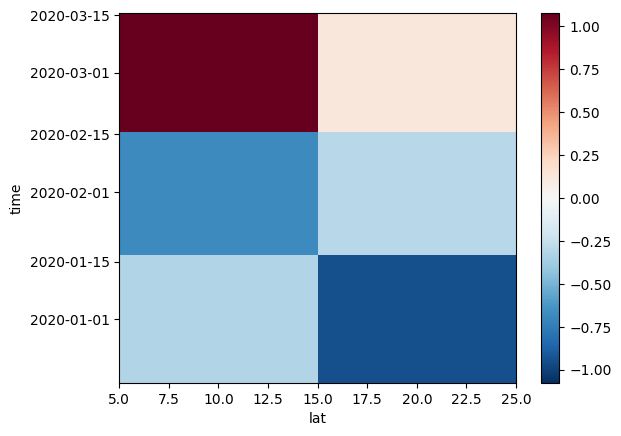

In [2]:
data = xr.DataArray(
    np.random.randn(3,2,3),
    dims = ("time", "lat", "lon"),
    coords = {
        "lat": [10,20],
        "time": pd.date_range(
            "2020-01", periods = 3, freq = "MS"
        ),
    },
)

data[0,:]
data.loc[:,10]
data.isel(lat=0)
data.sel(time="2020-01")
data.mean(dim=["time", "lat"])
data.isel(lon=0).plot();

In [3]:
import rasterio
import rasterio.features
import rasterio.warp

In [4]:
import sys
print(sys.executable)

/usr/local/Caskroom/mambaforge/base/envs/nmw-test/bin/python


In [5]:
with rasterio.open('/Users/ryanjoshi/Desktop/MODIS S3 downloads/ECO3ETPTJPL.001_EVAPOTRANSPIRATION_PT_JPL_ETdaily_doy2022156184219_aid0001.tif') as dataset:

    # Read the dataset's valid data mask as a ndarray.
    mask = dataset.dataset_mask()

    # Extract feature shapes and values from the array.
    for geom, val in rasterio.features.shapes(
            mask, transform=dataset.transform):

        # Transform shapes from the dataset's own coordinate
        # reference system to CRS84 (EPSG:4326).
        '''geom = rasterio.warp.transform_geom(
            dataset.crs, 'EPSG:4326', geom, precision=6)'''

        # Print GeoJSON shapes to stdout.
        print(dataset.crs)
        print(geom)

EPSG:4326
{'type': 'Polygon', 'coordinates': [[(-107.55192372387052, 33.89998227431894), (-107.55192372387052, 33.80215133817946), (-107.44588761244192, 33.80215133817946), (-107.44588761244192, 33.89998227431894), (-107.55192372387052, 33.89998227431894)]]}


In [6]:
dataset = rasterio.open('/Users/ryanjoshi/Desktop/MODIS S3 downloads/ECO3ETPTJPL.001_EVAPOTRANSPIRATION_PT_JPL_ETdaily_doy2022156184219_aid0001.tif')
dataset.name

'/Users/ryanjoshi/Desktop/MODIS S3 downloads/ECO3ETPTJPL.001_EVAPOTRANSPIRATION_PT_JPL_ETdaily_doy2022156184219_aid0001.tif'

In [ ]:
#new_dataset = rasterio.open('/Users/ryanjoshi/Desktop/MODIS S3 downloads/ECO3ETPTJPL.001_EVAPOTRANSPIRATION_PT_JPL_ETdaily_doy2022156184219_aid0001.tif')
#new_dataset.name

In [7]:
dataset.count

1

In [8]:
dataset.width

168

In [9]:
dataset.height

155

In [10]:
dataset.crs

CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]')

In [7]:
from rasterio.transform import from_gcps
from rasterio.control import GroundControlPoint

In [8]:
test_path = "/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20240406_ET.tif"

with rasterio.open(test_path) as src:
    data = src.read(1)
    data = np.where(data >= 32700, np.nan, data)
    print(data)

[[      nan       nan       nan ...       nan       nan       nan]
 [      nan       nan       nan ...       nan       nan       nan]
 [      nan       nan       nan ...       nan       nan       nan]
 ...
 [      nan       nan       nan ... 152.39233 161.00047       nan]
 [      nan       nan       nan ... 144.40862 168.88841       nan]
 [      nan       nan       nan ... 139.04951 144.65076 166.00804]]


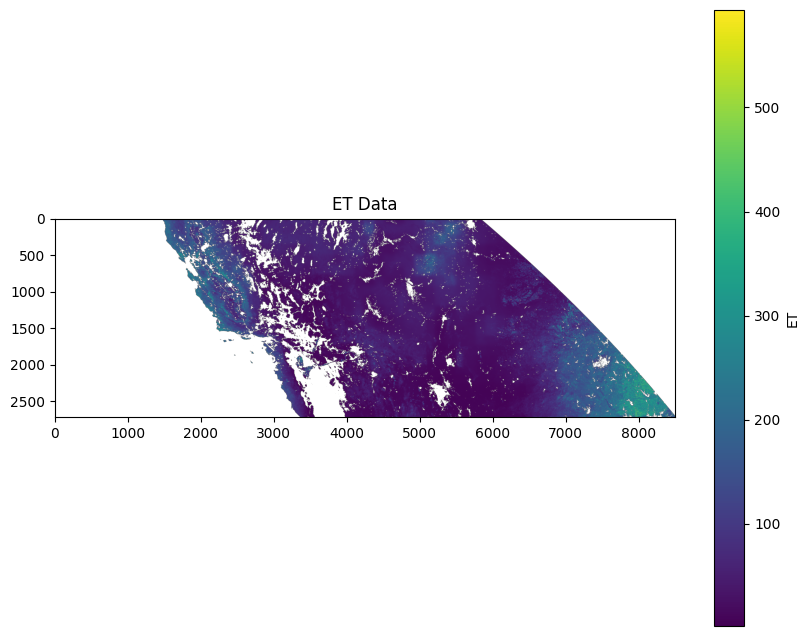

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.imshow(data)
plt.colorbar(label='ET')
plt.title('ET Data')
plt.show()

In [10]:
test_path = "/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20250501_PET.tif"

with rasterio.open(test_path) as src:
    data = src.read(1)
    data = np.where(data >= 32700, np.nan, data)
    print(data)

[[      nan       nan       nan ...       nan       nan       nan]
 [      nan       nan       nan ...       nan       nan       nan]
 [      nan       nan       nan ...       nan       nan       nan]
 ...
 [      nan       nan       nan ... 405.08334 402.14795       nan]
 [      nan       nan       nan ... 402.9377  397.6011        nan]
 [      nan       nan       nan ... 403.94223 397.40744 402.252  ]]


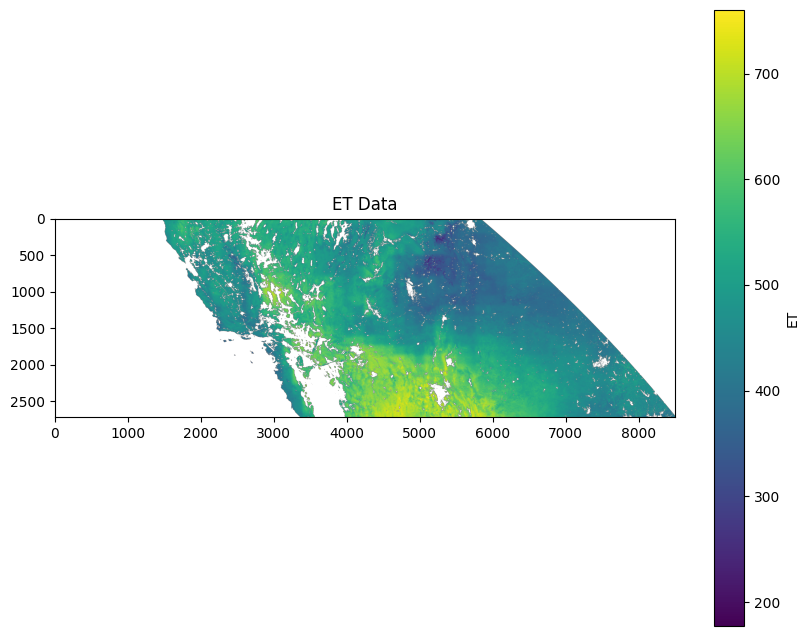

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.imshow(data)
plt.colorbar(label='ET')
plt.title('ET Data')
plt.show()

In [12]:
import os
all_files = os.listdir("/Users/ryanjoshi/Desktop/MODIS S3 downloads/")

monthly_files = []

for filename in all_files:
    if "202405" in filename and "_ET" in filename:
        monthly_files.append(filename)

monthly_files

#better to rely on some kind of reference -- load an image, get the dimensions of that image, and compare that to everything else
test_path = "/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20250501_PET.tif"
with rasterio.open(test_path) as src:
    data = src.read(1)
    data = np.where(data >= 32700, np.nan, data)
    data *= 0.000001

for file in monthly_files:
    test_path = "/Users/ryanjoshi/Desktop/MODIS S3 downloads/" + file
    with rasterio.open(test_path) as src:
        data += src.read(1)
        data = np.where(data >= 32700, np.nan, data)
        #print(data)

data /= len(monthly_files)
print(data)


pet_files = []

for filename in all_files:
    if "202405" in filename and "PET" in filename:
        pet_files.append(filename)

test_path = "/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20250501_PET.tif"
with rasterio.open(test_path) as src:
    pet_data = src.read(1)
    pet_data = np.where(pet_data >= 32700, np.nan, pet_data)
    pet_data *= 0.000001

for file in pet_files:
    test_path = "/Users/ryanjoshi/Desktop/MODIS S3 downloads/" + file
    with rasterio.open(test_path) as src:
        pet_data += src.read(1)
        pet_data = np.where(pet_data >= 32700, np.nan, pet_data)
        #print(data)

pet_data /= len(pet_files)
print(pet_data)

#each ET or PET file is an 8 day average
esi_data = data/pet_data
esi_data = np.where(esi_data >= 0.1, np.nan, esi_data)
print(esi_data)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.imshow(esi_data)
plt.colorbar(label='ESI')
plt.title('ESI Data')
plt.show()

ValueError: operands could not be broadcast together with shapes (2725,8496) (1526,1345) (2725,8496) 

In [12]:
import os
all_files = os.listdir("/Users/ryanjoshi/Desktop/MODIS S3 downloads/")
all_files += os.listdir("/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024")

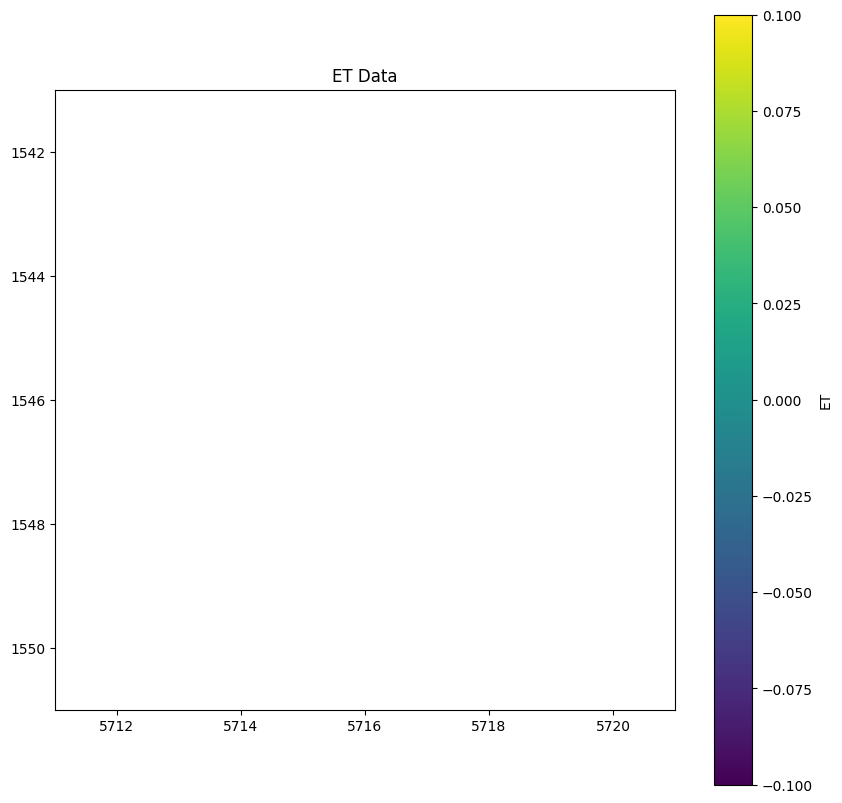

In [18]:
test_path = "/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20250501_PET.tif"

with rasterio.open(test_path) as src:
    data = src.read(1)
    data = np.where(data > 54.5, np.nan, data)
    data = np.where(data < 54.1, np.nan, data)
    #print(data)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
plt.imshow(data)
plt.colorbar(label='ET')
plt.title('ET Data')
plt.xlim(5711,5721)
plt.ylim(1551,1541)
plt.show()

In [ ]:
!pip install geopandas

In [13]:
import pandas as pd
import geopandas
import matplotlib.pyplot as plt
from geodatasets import get_path

In [14]:
import xarray
import rioxarray
from affine import Affine

In [ ]:
#%pip install xarray==2025.6.1

ERROR: Could not find a version that satisfies the requirement xarray==2025.6.1 (from versions: 0.7.0, 0.7.1, 0.7.2, 0.8.0rc1, 0.8.0, 0.8.1, 0.8.2, 0.9.0rc1, 0.9.0, 0.9.1, 0.9.2, 0.9.3, 0.9.4, 0.9.5, 0.9.6, 0.10.0rc1, 0.10.0rc2, 0.10.0, 0.10.1, 0.10.2, 0.10.3, 0.10.4, 0.10.5, 0.10.6, 0.10.7, 0.10.8, 0.10.9, 0.11.0, 0.11.1, 0.11.2, 0.11.3, 0.12.0, 0.12.1, 0.12.2, 0.12.3, 0.13.0, 0.14.0, 0.14.1, 0.15.0, 0.15.1, 0.16.0, 0.16.1, 0.16.2, 0.17.0, 0.18.0, 0.18.1, 0.18.2, 0.19.0, 0.20.0, 0.20.1, 0.20.2, 0.21.0, 0.21.1, 2022.3.0, 2022.6.0rc0, 2022.6.0, 2022.9.0, 2022.10.0, 2022.11.0, 2022.12.0, 2023.1.0, 2023.2.0, 2023.3.0, 2023.4.0, 2023.4.1, 2023.4.2, 2023.5.0, 2023.6.0, 2023.7.0, 2023.8.0, 2023.9.0, 2023.10.0, 2023.10.1, 2023.11.0, 2023.12.0, 2024.1.0, 2024.1.1, 2024.2.0, 2024.3.0, 2024.5.0, 2024.6.0, 2024.7.0)
ERROR: No matching distribution found for xarray==2025.6.1
Note: you may need to restart the kernel to use updated packages.


In [15]:
#import xarray
xds = rioxarray.open_rasterio(
    "/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20250501_ET.tif", 
    engine="rasterio")

In [ ]:
#from affine import Affine

In [16]:
rds = rioxarray.open_rasterio("/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20250501_ET.tif", decode_coords="all")
rds.rio.crs

CRS.from_wkt('PROJCS["WGS 84 / Pseudo-Mercator",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Mercator_1SP"],PARAMETER["central_meridian",0],PARAMETER["scale_factor",1],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],EXTENSION["PROJ4","+proj=merc +a=6378137 +b=6378137 +lat_ts=0 +lon_0=0 +x_0=0 +y_0=0 +k=1 +units=m +nadgrids=@null +wktext +no_defs"],AUTHORITY["EPSG","3857"]]')

In [21]:
#import xarray as xr
#import gdal
print(rioxarray.__version__)

0.19.0


In [22]:
import pyproj
print(pyproj.__version__)

3.7.1


In [25]:
import pyproj
print(pyproj.__proj_version__)

9.5.1


In [17]:
import sys
print(sys.executable)

/usr/local/Caskroom/mambaforge/base/envs/nmw-test/bin/python


In [27]:
%pip install pyproj==3.7.1

Note: you may need to restart the kernel to use updated packages.


In [18]:
xda = xarray.DataArray(1)
xda.rio.write_crs(4326, inplace=True)
xda.spatial_ref

<xarray.DataArray 'spatial_ref' ()> Size: 8B
array(0)
Coordinates:
    spatial_ref  int64 8B 0
Attributes:
    crs_wkt:                      GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["...
    semi_major_axis:              6378137.0
    semi_minor_axis:              6356752.314245179
    inverse_flattening:           298.257223563
    reference_ellipsoid_name:     WGS 84
    longitude_of_prime_meridian:  0.0
    prime_meridian_name:          Greenwich
    geographic_crs_name:          WGS 84
    horizontal_datum_name:        World Geodetic System 1984
    grid_mapping_name:            latitude_longitude
    spatial_ref:                  GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["...

In [19]:
xda.rio.crs

CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]')

In [20]:
rds.rio.write_crs(4326, inplace=True)
#rds.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=True)
rds.rio.write_coordinate_system(inplace=True)

#rds = rds.rename(x="longitude", y="latitude")

#rds = rds.rio.reproject("EPSG:4326")

<xarray.DataArray (band: 1, y: 2725, x: 8496)> Size: 93MB
[23151600 values with dtype=float32]
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 68kB -1.453e+07 -1.453e+07 ... -1.028e+07
  * y            (y) float64 22kB 4.866e+06 4.865e+06 ... 3.504e+06 3.504e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    _FillValue:     32700.0
    scale_factor:   1.0
    add_offset:     0.0

In [21]:
transform = Affine(3.0, 0.0, 466266.0, 0.0, -3.0, 8084700.0)
xda.rio.write_transform(transform, inplace=True)
xda.spatial_ref.GeoTransform

'466266.0 3.0 0.0 8084700.0 0.0 -3.0'

In [22]:
xda.rio.transform()

Affine(3.0, 0.0, 466266.0,
       0.0, -3.0, 8084700.0)

In [23]:
import urllib
import geojson

In [24]:
geometry = ''' {"type": "Polygon",
               "coordinates": [
                [[-109.05, 31.333],
                [-109.05, 36.999],
                 [-103, 36.999],
                [-103, 31.333]]]}'''

cropping_geometries = [geojson.loads(geometry)]
xds = rioxarray.open_rasterio('/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20250501_ET.tif')
cropped = xds.rio.clip(geometries=cropping_geometries, crs=4326)

In [35]:
import pyproj
print(pyproj.__proj_version__)

9.5.1


In [25]:
cropped

<xarray.DataArray (band: 1, y: 1526, x: 1347)> Size: 8MB
array([[[56.05772  , 56.702312 , 56.70582  , ..., 81.643105 ,
         81.7709   , 82.24886  ],
        [55.311386 , 55.770554 , 56.228333 , ..., 82.565765 ,
         82.62166  , 83.73735  ],
        [55.013046 , 55.254257 , 55.906826 , ..., 82.24882  ,
         82.425995 , 82.98256  ],
        ...,
        [13.702225 , 13.607969 , 14.792874 , ..., 15.7801075,
         17.137785 , 17.75787  ],
        [15.758725 , 14.838384 , 13.789731 , ..., 15.920914 ,
         17.08932  , 17.68497  ],
        [15.607399 , 17.527592 , 17.061396 , ..., 15.820736 ,
         17.021313 , 17.478968 ]]], shape=(1, 1526, 1347), dtype=float32)
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 11kB -1.214e+07 -1.214e+07 ... -1.147e+07
  * y            (y) float64 12kB 4.439e+06 4.438e+06 ... 3.677e+06 3.676e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    _FillValue:     32700.0

In [26]:
def valid_imshow_data(data):
    data = np.asarray(data)
    if data.ndim == 2:
        return True
    elif data.ndim == 3:
        if 3 <= data.shape[2] <= 4:
            return True
        else:
            print('The "data" has 3 dimensions but the last dimension '
                  'must have a length of 3 (RGB) or 4 (RGBA), not "{}".'
                  ''.format(data.shape[2]))
            return False
    else:
        print('To visualize an image the data must be 2 dimensional or '
              '3 dimensional, not "{}".'
              ''.format(data.ndim))
        return False

valid_imshow_data(cropped)

cropped.ndim

The "data" has 3 dimensions but the last dimension must have a length of 3 (RGB) or 4 (RGBA), not "1347".


3

In [27]:
if cropped.shape[0] == 1:
    cropped = cropped[0, :, :]

cropped.ndim

2

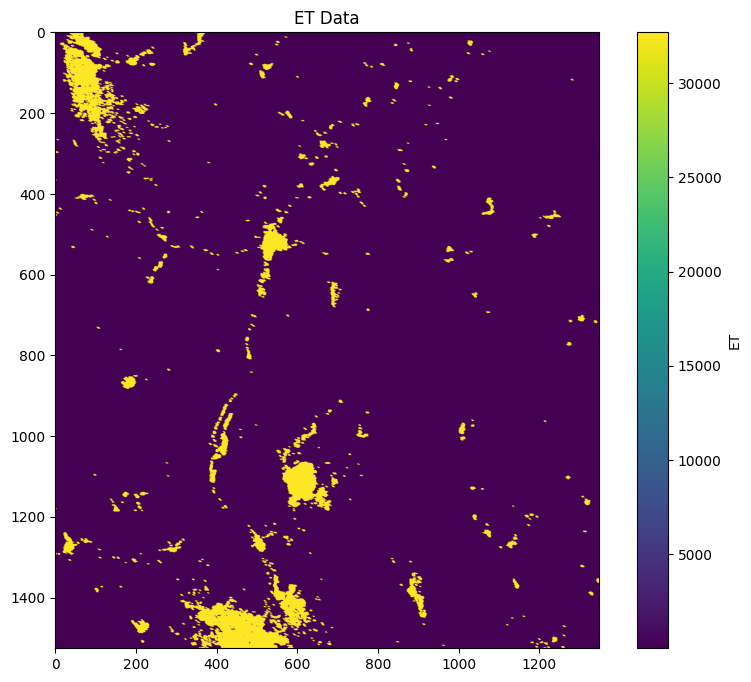

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.imshow(cropped)
plt.colorbar(label='ET')
plt.title('ET Data')
plt.show()

In [28]:
geometry = ''' {"type": "Polygon",
               "coordinates": [
                [[-104.88, 34.45],
                [-104.84, 34.45],
                 [-104.84, 34.49],
                [-104.88, 34.49]]]}'''

cropping_geometries = [geojson.loads(geometry)]
xds = rioxarray.open_rasterio('/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20250501_ET.tif')
beam = xds.rio.clip(geometries=cropping_geometries, crs=4326)

In [29]:
if beam.shape[0] == 1:
    beam = beam[0, :, :]

beam.ndim

2

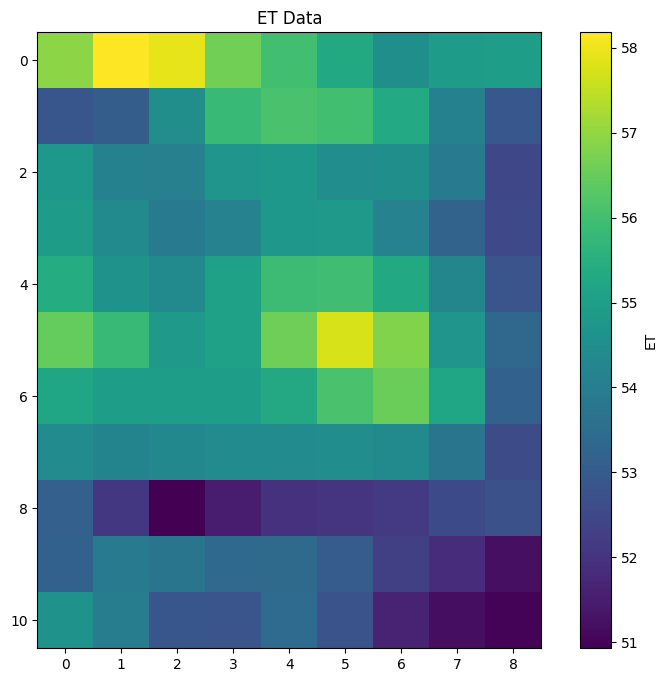

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.imshow(beam)
plt.colorbar(label='ET')
plt.title('ET Data')
plt.show()

In [43]:
geometry = ''' {"type": "Polygon",
               "coordinates": [
                [[-109.05, 31.333],
                [-109.045, 36.999],
                 [-103, 36.999],
                [-103, 32.002],
                [-106.618, 32.002],
                [-106.618, 31.781],
                [-108.210, 31.781],
                [-108.210, 31.333]]]}'''

cropping_geometries = [geojson.loads(geometry)]
xds = rioxarray.open_rasterio('/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20250501_ET.tif')
new_mexico = xds.rio.clip(geometries=cropping_geometries, crs=4326)

In [44]:
if new_mexico.shape[0] == 1:
    new_mexico = new_mexico[0, :, :]

new_mexico.ndim

2

In [45]:
new_mexico = np.where(new_mexico >= 32700, np.nan, new_mexico)

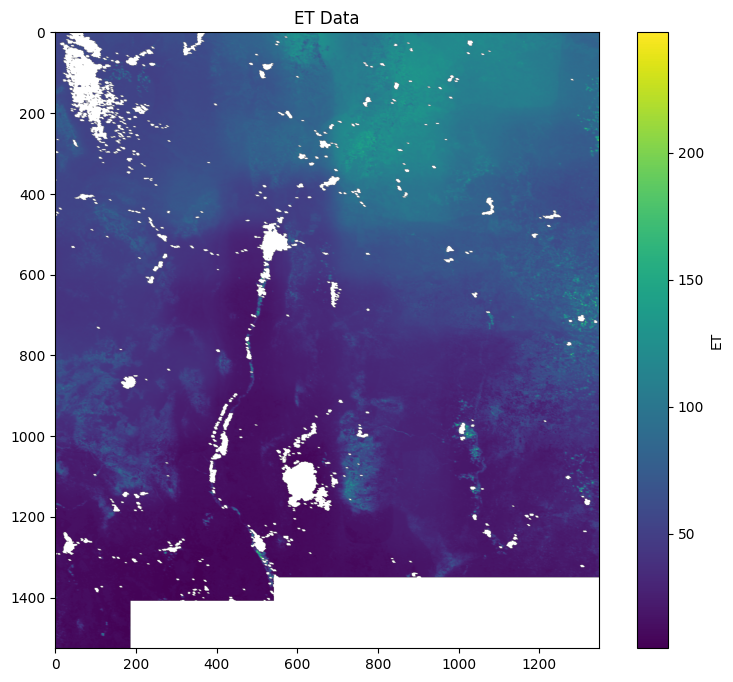

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.imshow(new_mexico)
plt.colorbar(label='ET')
plt.title('ET Data')
plt.show()

In [29]:
new_mexico = np.where(new_mexico >= 32700, np.nan, new_mexico)

NameError: name 'new_mexico' is not defined

['MOD16A2_MERGED_20230922_ET.tif', 'MOD16A2_MERGED_20230930_ET.tif', 'MOD16A2_MERGED_20230906_ET.tif', 'MOD16A2_MERGED_20230914_ET.tif']


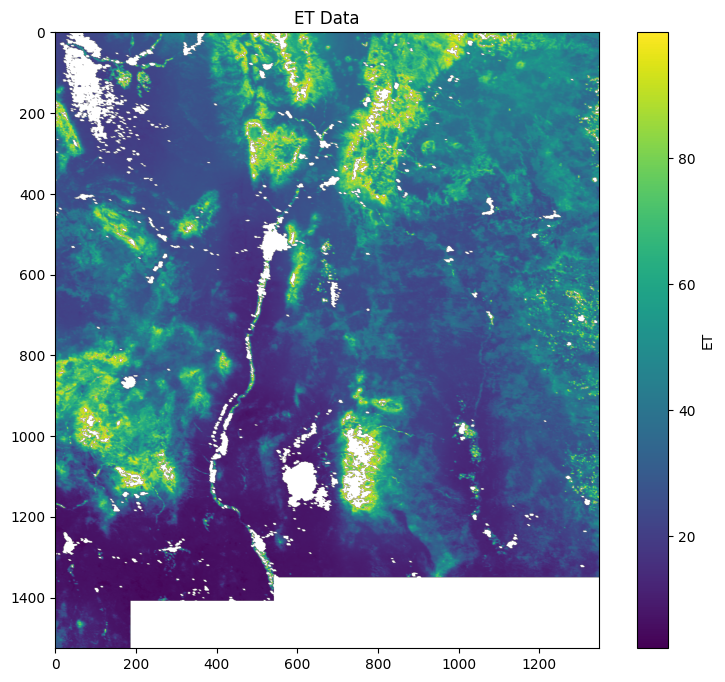

In [46]:
# monthly average
geometry = ''' {"type": "Polygon",
               "coordinates": [
                [[-109.05, 31.333],
                [-109.045, 36.999],
                [-103, 36.999],
                [-103, 32.002],
                [-106.618, 32.002],
                [-106.618, 31.781],
                [-108.210, 31.781],
                [-108.210, 31.333]]]}'''

cropping_geometries = [geojson.loads(geometry)]

xds = rioxarray.open_rasterio('/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20250501_ET.tif')
new_mexico = xds.rio.clip(geometries=cropping_geometries, crs=4326)
new_mexico = new_mexico[0, :, :]
new_mexico = new_mexico * 0.00000001

monthly_files = []

month = int(input("Choose a year and month (format YYYYMM)"))
str_month = str(month)

for filename in all_files:
    if str_month in filename and "_ET" in filename and "MERGED" in filename:
        monthly_files.append(filename)

print(monthly_files)

for file in monthly_files:
    xds = rioxarray.open_rasterio('/Users/ryanjoshi/Desktop/MODIS S3 downloads/' + file)
    new_mexico_2 = xds.rio.clip(geometries=cropping_geometries, crs=4326)
    new_mexico_2 = new_mexico_2[0, :, :]
    new_mexico += new_mexico_2

new_mexico /= len(monthly_files)
#print(new_mexico)

new_mexico = np.where(new_mexico >= 32700, np.nan, new_mexico)
threshold = int(input("Choose an ET threshold (I would recommend a threshold between 50 and 150)"))
new_mexico = np.where(new_mexico >= threshold, np.nan, new_mexico)

'''pet_files = []

for filename in all_files:
    if "202405" in filename and "PET" in filename:
        pet_files.append(filename)

pet_data = np.zeros((2725, 8496))

for file in pet_files:
    test_path = "/Applications/MODIS_S3_downloads/" + file
    with rasterio.open(test_path) as src:
        pet_data += src.read(1)
        pet_data = np.where(pet_data >= 32700, np.nan, pet_data)
        #print(data)

pet_data /= len(pet_files)
print(pet_data)'''

#each ET or PET file is an 8 day average
'''esi_data = data/pet_data
esi_data = np.where(esi_data >= 0.1, np.nan, esi_data)
print(esi_data)'''

import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.imshow(new_mexico)
plt.colorbar(label='ET')
plt.title('ET Data')
plt.show()

 {"type": "Polygon",
               "coordinates": [
                [[-104.31, 33.7],
                [-104.31, 33.85],
                [-104.16, 33.85],
                [-104.16, 33.7]]]}


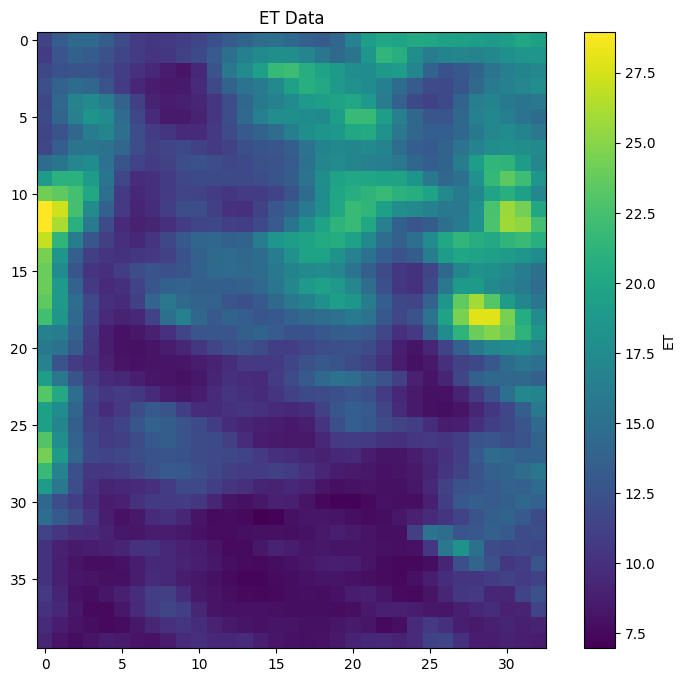

In [ ]:
# monthly average with coordinate choices

coord1 = str(input("Choose a western boundary"))
coord2 = str(input("Choose a southern boundary"))
coord3 = str(input("Choose a eastern boundary"))
coord4 = str(input("Choose a northern boundary"))

geometry = ''' {"type": "Polygon",
               "coordinates": [
                [[''' + coord1 + ''', ''' + coord2 + '''],
                [''' + coord1 + ''', ''' + coord4 + '''],
                [''' + coord3 + ''', ''' + coord4 + '''],
                [''' + coord3 + ''', ''' + coord2 + ']]]}'''
print(geometry)

cropping_geometries = [geojson.loads(geometry)]

xds = rioxarray.open_rasterio('/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20250501_ET.tif')
new_mexico = xds.rio.clip(geometries=cropping_geometries, crs=4326)
new_mexico = new_mexico[0, :, :]
new_mexico = new_mexico * 0.00000001

monthly_files = []

month = int(input("Choose a year and month (format YYYYMM)"))
str_month = str(month)

for filename in all_files:
    if str_month in filename and "_ET" in filename and "MERGED" in filename:
        monthly_files.append(filename)

monthly_files

for file in monthly_files:
    xds = rioxarray.open_rasterio('/Users/ryanjoshi/Desktop/MODIS S3 downloads/' + file)
    new_mexico_2 = xds.rio.clip(geometries=cropping_geometries, crs=4326)
    new_mexico_2 = new_mexico_2[0, :, :]
    new_mexico += new_mexico_2

new_mexico /= len(monthly_files)
#print(new_mexico)

new_mexico = np.where(new_mexico >= 32700, np.nan, new_mexico)
min_threshold = int(input("Choose an minimum ET threshold (type 0 if N/A)"))
max_threshold = int(input("Choose an maximum ET threshold (type 32700 if N/A)"))
new_mexico = np.where(new_mexico < min_threshold, np.nan, new_mexico)
new_mexico = np.where(new_mexico > max_threshold, np.nan, new_mexico)

'''pet_files = []

for filename in all_files:
    if "202405" in filename and "PET" in filename:
        pet_files.append(filename)

pet_data = np.zeros((2725, 8496))

for file in pet_files:
    test_path = "/Applications/MODIS_S3_downloads/" + file
    with rasterio.open(test_path) as src:
        pet_data += src.read(1)
        pet_data = np.where(pet_data >= 32700, np.nan, pet_data)
        #print(data)

pet_data /= len(pet_files)
print(pet_data)'''

#each ET or PET file is an 8 day average
'''esi_data = data/pet_data
esi_data = np.where(esi_data >= 0.1, np.nan, esi_data)
print(esi_data)'''

import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.imshow(new_mexico)
plt.colorbar(label='ET')
plt.title('ET Data')
plt.show()

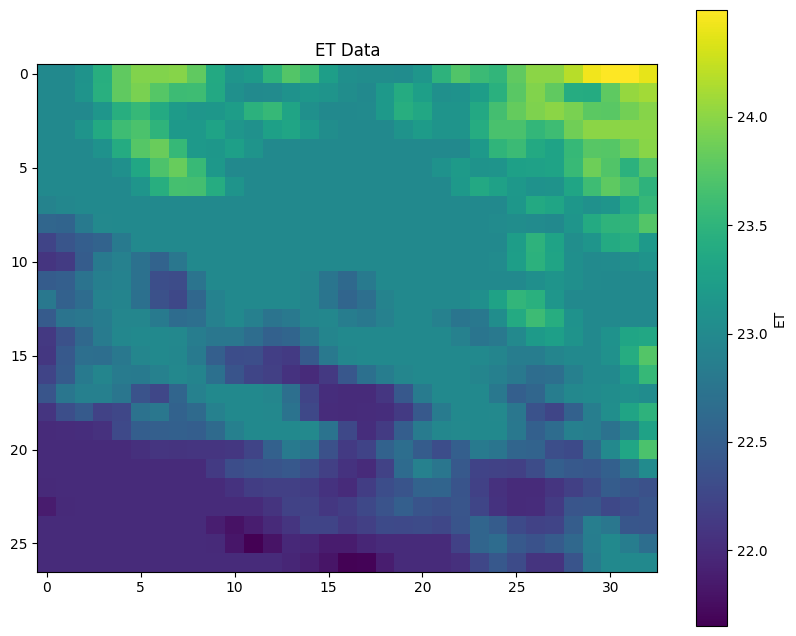

In [ ]:
#test coordinate algorithm for single TIF file to ensure it matches QGIS

coord1 = str(input("Choose a western boundary"))
coord2 = str(input("Choose a southern boundary"))
coord3 = str(input("Choose a eastern boundary"))
coord4 = str(input("Choose a northern boundary"))

geometry = ''' {"type": "Polygon",
               "coordinates": [
                [[''' + coord1 + ''', ''' + coord2 + '''],
                [''' + coord1 + ''', ''' + coord4 + '''],
                [''' + coord3 + ''', ''' + coord4 + '''],
                [''' + coord3 + ''', ''' + coord2 + ']]]}'''

cropping_geometries = [geojson.loads(geometry)]

xds = rioxarray.open_rasterio('/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20241210_ET.tif')
#xds.rio.write_crs(4326, inplace=True)
new_mexico = xds.rio.clip(geometries=cropping_geometries, crs=4326)
new_mexico = new_mexico[0, :, :]

new_mexico = np.where(new_mexico >= 32700, np.nan, new_mexico)
min_threshold = float(input("Choose an minimum ET threshold (0 if N/A)"))
max_threshold = float(input("Choose an maximum ET threshold (32700 if N/A)"))
new_mexico = np.where(new_mexico < min_threshold, np.nan, new_mexico)
new_mexico = np.where(new_mexico > max_threshold, np.nan, new_mexico)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.imshow(new_mexico)
plt.colorbar(label='ET')
plt.title('ET Data')
plt.show()

[[nan nan nan ... 41. 41. 42.]
 [nan nan nan ... 41. 41. 42.]
 [nan nan nan ... 42. 41. nan]
 ...
 [nan 54. 56. ... nan nan nan]
 [nan 55. 55. ... nan nan nan]
 [58. 55. 56. ... nan nan nan]]


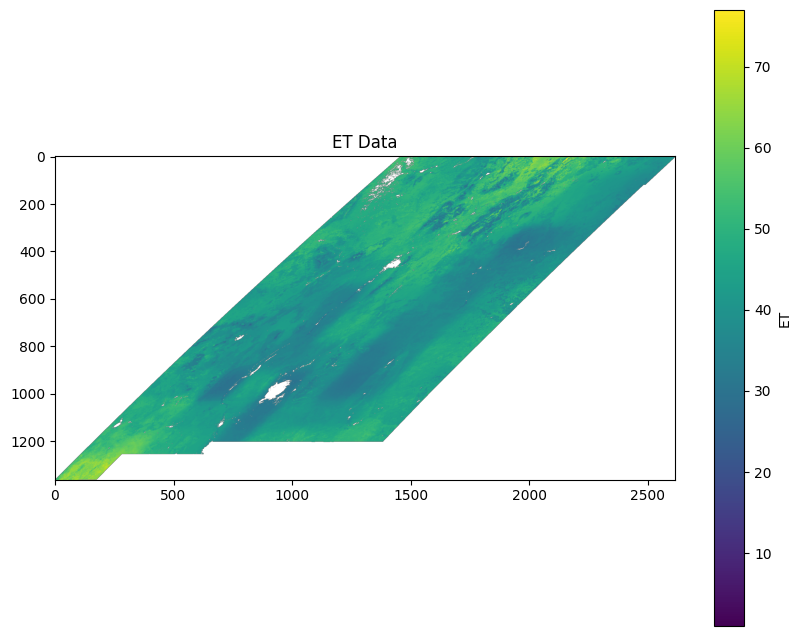

In [ ]:
test_path = "/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2004361000000_aid0001.tif"

with rasterio.open(test_path) as src:
    data = src.read(1)
    data = np.where(data >= 32700, np.nan, data)
    print(data)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.imshow(data)
plt.colorbar(label='ET')
plt.title('ET Data')
plt.show()

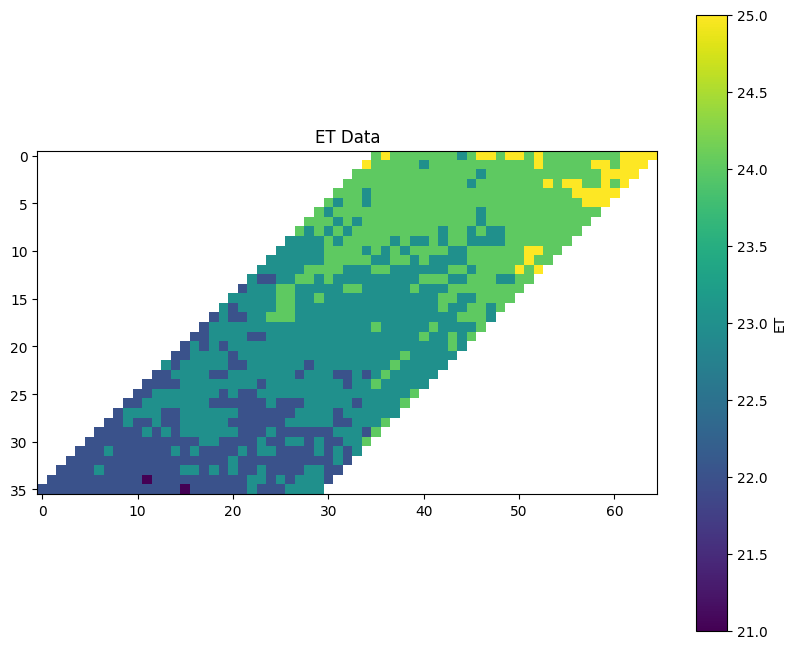

In [ ]:
#test coordinate algorithm for single TIF file to ensure it matches QGIS

coord1 = str(input("Choose a western boundary"))
coord2 = str(input("Choose a southern boundary"))
coord3 = str(input("Choose a eastern boundary"))
coord4 = str(input("Choose a northern boundary"))

geometry = ''' {"type": "Polygon",
               "coordinates": [
                [[''' + coord1 + ''', ''' + coord2 + '''],
                [''' + coord1 + ''', ''' + coord4 + '''],
                [''' + coord3 + ''', ''' + coord4 + '''],
                [''' + coord3 + ''', ''' + coord2 + ']]]}'''

cropping_geometries = [geojson.loads(geometry)]

xds = rioxarray.open_rasterio('/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024345000000_aid0001.tif')
#xds.rio.write_crs(4326, inplace=True)
new_mexico = xds.rio.clip(geometries=cropping_geometries, crs=4326)
new_mexico = new_mexico[0, :, :]

new_mexico = np.where(new_mexico >= 32700, np.nan, new_mexico)
min_threshold = float(input("Choose an minimum ET threshold (0 if N/A)"))
max_threshold = float(input("Choose an maximum ET threshold (32700 if N/A)"))
new_mexico = np.where(new_mexico < min_threshold, np.nan, new_mexico)
new_mexico = np.where(new_mexico > max_threshold, np.nan, new_mexico)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.imshow(new_mexico)
plt.colorbar(label='ET')
plt.title('ET Data')
plt.show()

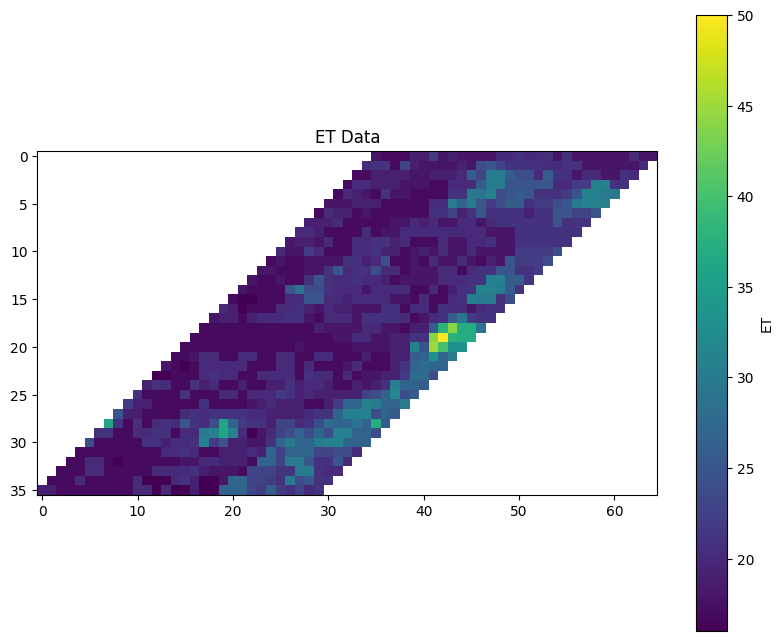

In [ ]:
coord1 = str(input("Choose a western boundary"))
coord2 = str(input("Choose a southern boundary"))
coord3 = str(input("Choose a eastern boundary"))
coord4 = str(input("Choose a northern boundary"))

geometry = ''' {"type": "Polygon",
               "coordinates": [
                [[''' + coord1 + ''', ''' + coord2 + '''],
                [''' + coord1 + ''', ''' + coord4 + '''],
                [''' + coord3 + ''', ''' + coord4 + '''],
                [''' + coord3 + ''', ''' + coord2 + ']]]}'''

cropping_geometries = [geojson.loads(geometry)]

xds = rioxarray.open_rasterio('/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2005089000000_aid0001.tif')
#xds.rio.write_crs(4326, inplace=True)
new_mexico = xds.rio.clip(geometries=cropping_geometries, crs=4326)
new_mexico = new_mexico[0, :, :]

new_mexico = np.where(new_mexico >= 32700, np.nan, new_mexico)
min_threshold = float(input("Choose an minimum ET threshold (0 if N/A)"))
max_threshold = float(input("Choose an maximum ET threshold (32700 if N/A)"))
new_mexico = np.where(new_mexico < min_threshold, np.nan, new_mexico)
new_mexico = np.where(new_mexico > max_threshold, np.nan, new_mexico)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.imshow(new_mexico)
plt.colorbar(label='ET')
plt.title('ET Data')
plt.show()

In [30]:

import datetime
from datetime import date, timedelta

In [48]:
class DroughtDetection:
    def __init__(
            self, 
            geojson_file: str,
            date: datetime.date
    ):
        
        self.geojson_file = geojson_file #base of constructor
        self.date = date #base of constructor

    def generate_tiffs(self, start, end):
        from rasterio import shutil

        list_of_tiffs = []

        def check_for_tiff(date):
            #xds = rioxarray.open_rasterio('/Applications/MODIS_S3_downloads/MOD16A2_MERGED_' + date + '_ET.tif')
            if rasterio.shutil.exists(('/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_' + date + '_ET.tif')):
                list_of_tiffs.append(('/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_' + date + '_ET.tif'))

        current_date = date.today()
        start_date = current_date - timedelta(days=start) 

        while start_date <= current_date - timedelta(days=end):
            string_date = str(start_date)
            string_date = string_date.replace("-", "")
            check_for_tiff(string_date)
            start_date += timedelta(days=1)

        return list_of_tiffs

    def generate_static_tiffs(self, start_year, start_month, start_day, end_year, end_month, end_day):
        from rasterio import shutil

        list_of_tiffs = []

        def check_for_tiff(date):
            #xds = rioxarray.open_rasterio('/Applications/MODIS_S3_downloads/MOD16A2_MERGED_' + date + '_ET.tif')
            if rasterio.shutil.exists(('/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_' + date + '_ET.tif')):
                list_of_tiffs.append(('/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_' + date + '_ET.tif'))

        #current_date = date.today()
        start_date = date(start_year, start_month, start_day)
        end = date(end_year, end_month, end_day)

        while start_date <= end:
            string_date = str(start_date)
            string_date = string_date.replace("-", "")
            check_for_tiff(string_date)
            start_date += timedelta(days=1)
            
        return list_of_tiffs

    def generate_et_tiffs(self, year, month, day):
        from rasterio import shutil

        list_of_tiffs = []

        def check_for_tiff(date):
            #xds = rioxarray.open_rasterio('/Applications/MODIS_S3_downloads/MOD16A2_MERGED_' + date + '_ET.tif')
            if rasterio.shutil.exists(('/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy' + date + '000000_aid0001.tif')):
                list_of_tiffs.append(('/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy' + date + '000000_aid0001.tif'))

        def find_doy(date):
            date = date.replace("-", "")
            if date[4:6] == "01":
                day = int(date[6:8])
                if day<10:
                    date = date.replace(date[4:8], "00" + str(day))
                else:
                    date = date.replace(date[4:8], "0" + str(day))
            elif date[4:6] == "02":
                day = int(date[6:8])
                num = 31 + day
                date = date.replace(date[4:8], "0" + str(num))
            elif date[4:6] == "03":
                day = int(date[6:8])
                num = 59 + day
                if (int(date[2:4]))%4 == 0:
                    num+= 1
                date = date.replace(date[4:8], "0" + str(num))
            elif date[4:6] == "04":
                day = int(date[6:8])
                num = 90 + day
                if (int(date[2:4]))%4 == 0:
                    num+= 1
                if num<100:
                    date = date.replace(date[4:8], "0" + str(num))
                else:
                    date = date.replace(date[4:8], str(num))
            elif date[4:6] == "05":
                day = int(date[6:8])
                num = 120 + day
                if (int(date[2:4]))%4 == 0:
                    num+= 1
                date = date.replace(date[4:8], str(num))
            elif date[4:6] == "06":
                day = int(date[6:8])
                num = 151 + day
                if (int(date[2:4]))%4 == 0:
                    num+= 1
                date = date.replace(date[4:8], str(num))
            elif date[4:6] == "07":
                day = int(date[6:8])
                num = 181 + day
                if (int(date[2:4]))%4 == 0:
                    num+= 1
                date = date.replace(date[4:8], str(num))
            elif date[4:6] == "08":
                day = int(date[6:8])
                num = 212 + day
                if (int(date[2:4]))%4 == 0:
                    num+= 1
                date = date.replace(date[4:8], str(num))
            elif date[4:6] == "09":
                day = int(date[6:8])
                num = 243 + day
                if (int(date[2:4]))%4 == 0:
                    num+= 1
                date = date.replace(date[4:8], str(num))
            elif date[4:6] == "10":
                day = int(date[6:8])
                num = 273 + day
                if (int(date[2:4]))%4 == 0:
                    num+= 1
                date = date.replace(date[4:8], str(num))
            elif date[4:6] == "11":
                day = int(date[6:8])
                num = 304 + day
                if (int(date[2:4]))%4 == 0:
                    num+= 1
                date = date.replace(date[4:8], str(num))
            elif date[4:6] == "12":
                day = int(date[6:8])
                num = 334 + day
                if (int(date[2:4]))%4 == 0:
                    num+= 1
                date = date.replace(date[4:8], str(num))
            else:
                print("Invalid date.")
            return date

        new_date = date(year, month, day)
        new_date = str(new_date)
        new_date = find_doy(new_date)
        check_for_tiff(new_date)

        '''start_date = date(start_year, start_month, start_day)
        end = date(end_year, end_month, end_day)

        while start_date <= end:
            string_date = str(start_date)
            string_date = find_doy(string_date)
            check_for_tiff(string_date)
            start_date += timedelta(days=1)'''

        return list_of_tiffs

    def choose_coordinates(self, coord1, coord2, coord3, coord4):
        geometry = ''' {"type": "Polygon",
               "coordinates": [
                [[''' + str(coord1) + ''', ''' + str(coord2) + '''],
                [''' + str(coord1) + ''', ''' + str(coord4) + '''],
                [''' + str(coord3) + ''', ''' + str(coord4) + '''],
                [''' + str(coord3) + ''', ''' + str(coord2) + ']]]}'''
        return geometry

    def generate_threshold(self, list_of_tiffs, low, high):
        #return threshold #get this code to run in jupyter notebook
        geometry = ''' {"type": "Polygon",
               "coordinates": [
                [[-109.05, 31.333],
                [-109.045, 36.999],
                [-103, 36.999],
                [-103, 32.002],
                [-106.618, 32.002],
                [-106.618, 31.781],
                [-108.210, 31.781],
                [-108.210, 31.333]]]}'''

        cropping_geometries = [geojson.loads(geometry)]

        xds = rioxarray.open_rasterio('/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20250501_ET.tif')
        new_mexico = xds.rio.clip(geometries=cropping_geometries, crs=4326)
        new_mexico = new_mexico[0, :, :]
        new_mexico = new_mexico * 0.00000001

        for tiff in list_of_tiffs:
            xds = rioxarray.open_rasterio(tiff)
            new_mexico_2 = xds.rio.clip(geometries=cropping_geometries, crs=4326)
            new_mexico_2 = new_mexico_2[0, :, :]
            new_mexico += new_mexico_2

        new_mexico /= len(monthly_files)
            #print(new_mexico)

        new_mexico = np.where(new_mexico >= 32700, np.nan, new_mexico)
        new_mexico = np.where(new_mexico < low, np.nan, new_mexico)
        new_mexico = np.where(new_mexico > high, np.nan, new_mexico)

        plt.figure(figsize=(10,8))
        plt.imshow(new_mexico)
        plt.colorbar(label='ET')
        plt.title('ET Data')
        return plt.show()

    def generate_threshold_coords(self, coords, list_of_tiffs, low, high):
        #return threshold #get this code to run in jupyter notebook
        geometry = coords

        cropping_geometries = [geojson.loads(geometry)]

        xds = rioxarray.open_rasterio('/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20250501_ET.tif')
        new_mexico = xds.rio.clip(geometries=cropping_geometries, crs=4326)
        new_mexico = new_mexico[0, :, :]
        new_mexico = new_mexico * 0.00000001

        for tiff in list_of_tiffs:
            xds = rioxarray.open_rasterio(tiff)
            new_mexico_2 = xds.rio.clip(geometries=cropping_geometries, crs=4326)
            new_mexico_2 = new_mexico_2[0, :, :]
            new_mexico += new_mexico_2

        new_mexico /= len(monthly_files)
            #print(new_mexico)

        new_mexico = np.where(new_mexico >= 32700, np.nan, new_mexico)
        new_mexico = np.where(new_mexico < low, np.nan, new_mexico)
        new_mexico = np.where(new_mexico > high, np.nan, new_mexico)

        plt.figure(figsize=(10,8))
        plt.imshow(new_mexico)
        plt.colorbar(label='ET')
        plt.title('ET Data')
        return plt.show()

NameError: name 'datetime' is not defined

In [49]:
import datetime

model = DroughtDetection(
    geojson_file = "path/to/geojson",
    date = datetime.datetime.now()
)

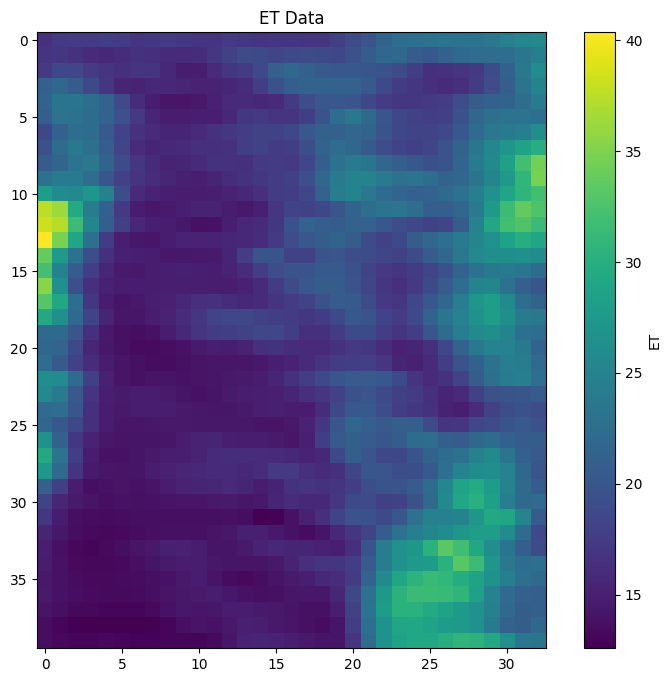

['/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20240617_ET.tif', '/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20240625_ET.tif', '/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20240703_ET.tif', '/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20240711_ET.tif', '/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20240719_ET.tif', '/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20240727_ET.tif', '/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20240804_ET.tif']
 {"type": "Polygon",
               "coordinates": [
                [[-104.31, 33.7],
                [-104.31, 33.85],
                [-104.16, 33.85],
                [-104.16, 33.7]]]}


In [50]:
list_of_tiffs = model.generate_static_tiffs(2024, 6, 17, 2024, 8, 4)
#list_of_tiffs = model.generate_tiffs(390, 340)
coords = model.choose_coordinates(-104.31, 33.7, -104.16, 33.85)
model.generate_threshold_coords(coords, list_of_tiffs, 0, 100)
print(list_of_tiffs)
print(coords)

In [ ]:
list_of_tiffs = model.generate_et_tiffs(2024, 11, 16)
print(list_of_tiffs)
#list_of_tiffs = model.generate_tiffs(390, 340)
coords = model.choose_coordinates(-104.31, 33.7, -104.16, 33.85)
model.generate_threshold_coords(coords, list_of_tiffs, 0, 100)
print(list_of_tiffs)
print(coords)

['/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024321000000_aid0001.tif']


NoDataInBounds: No data found in bounds.

In [49]:
current_date = date.today() - timedelta(days=144)

current_date = str(current_date)

def find_doy(date):
    date = date.replace("-", "")
    if date[4:6] == "01":
        day = int(date[6:8])
        if day<10:
            date = date.replace(date[4:8], "00" + str(day))
        else:
            date = date.replace(date[4:8], "0" + str(day))
    elif date[4:6] == "02":
        day = int(date[6:8])
        num = 31 + day
        date = date.replace(date[4:8], "0" + str(num))
    elif date[4:6] == "03":
        day = int(date[6:8])
        num = 59 + day
        if (int(date[2:4]))%4 == 0:
            num+= 1
        date = date.replace(date[4:8], "0" + str(num))
    elif date[4:6] == "04":
        day = int(date[6:8])
        num = 90 + day
        if (int(date[2:4]))%4 == 0:
            num+= 1
        if num<100:
            date = date.replace(date[4:8], "0" + str(num))
        else:
            date = date.replace(date[4:8], str(num))
    elif date[4:6] == "05":
        day = int(date[6:8])
        num = 120 + day
        if (int(date[2:4]))%4 == 0:
            num+= 1
        date = date.replace(date[4:8], str(num))
    elif date[4:6] == "06":
        day = int(date[6:8])
        num = 151 + day
        if (int(date[2:4]))%4 == 0:
            num+= 1
        date = date.replace(date[4:8], str(num))
    elif date[4:6] == "07":
        day = int(date[6:8])
        num = 181 + day
        if (int(date[2:4]))%4 == 0:
            num+= 1
        date = date.replace(date[4:8], str(num))
    elif date[4:6] == "08":
        day = int(date[6:8])
        num = 212 + day
        if (int(date[2:4]))%4 == 0:
            num+= 1
        date = date.replace(date[4:8], str(num))
    elif date[4:6] == "09":
        day = int(date[6:8])
        num = 243 + day
        if (int(date[2:4]))%4 == 0:
            num+= 1
        date = date.replace(date[4:8], str(num))
    elif date[4:6] == "10":
        day = int(date[6:8])
        num = 273 + day
        if (int(date[2:4]))%4 == 0:
            num+= 1
        date = date.replace(date[4:8], str(num))
    elif date[4:6] == "11":
        day = int(date[6:8])
        num = 304 + day
        if (int(date[2:4]))%4 == 0:
            num+= 1
        date = date.replace(date[4:8], str(num))
    elif date[4:6] == "12":
        day = int(date[6:8])
        num = 334 + day
        if (int(date[2:4]))%4 == 0:
            num+= 1
        date = date.replace(date[4:8], str(num))
    else:
        print("Invalid date.")
    return date

find_doy("2024-07-31")

NameError: name 'date' is not defined

In [52]:
import xarray as xr
import geopandas as gpd
import json
import pyproj
from pyproj import CRS

#geojson_path = "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20190917.json"
gdf = gpd.read_file("/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20190917.json")

# Drop geometry column to create xarray dataset from attribute table
ds = xr.Dataset.from_dataframe(gdf.drop(columns='geometry'))

import geopandas as gpd
import rasterio
from rasterio.features import rasterize
from affine import Affine
import numpy as np

# Read the GeoJSON
gdf = gpd.read_file("usdm_20190917.json")

DataSourceError: usdm_20190917.json: No such file or directory

In [31]:
import os
import json

# Directory containing the GeoJSON files
geojson_dir = "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data"

# Initialize an empty list to store all features
combined_features = []

# Step 1: Iterate through all files in the directory
for filename in os.listdir(geojson_dir):
    if filename.endswith(".geojson"):  # Only process GeoJSON files
        file_path = os.path.join(geojson_dir, filename)
        
        # Step 2: Load the GeoJSON file
        with open(file_path, "r") as f:
            geojson_data = json.load(f)
        
        # Step 3: Append features to the combined list
        combined_features.extend(geojson_data["features"])

# Step 4: Create a new GeoJSON object
combined_geojson = {
    "type": "FeatureCollection",
    "features": combined_features
}

# Step 5: Save the combined GeoJSON to a new file
output_file = "combined_data_2.tiff"
with open(output_file, "w") as f:
    json.dump(combined_geojson, f, indent=4)

print(f"Combined GeoJSON saved to '{output_file}'.")

Combined GeoJSON saved to 'combined_data_2.tiff'.


In [33]:
'''def find_doy(year, month, day):
    date_obj = datetime.datetime(year, month, day)
    day_of_year = date_obj.strftime("%j")
    return day_of_year'''


drought_monitor_mapping = [
    {
        "date": "2024-01-01",
        "modis_files": [
            "/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024001000000_aid0001.tif",
        ],
        "usdm_file": "usdm_20240102.json"
    },
    {
        "date": "2024-01-09",
        "modis_files": [
            "/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024009000000_aid0001.tif",
        ],
        "usdm_file": "usdm_20240109.json"
    },
    {
        "date": "2024-01-17",
        "modis_files": [
            "/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024017000000_aid0001.tif",
        ],
        "usdm_file": "usdm_20240116.json"
    },
    {
        "date": "2024-01-25",
        "modis_files": [
            "/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024025000000_aid0001.tif",
        ],
        "usdm_file": "usdm_20240123.json"
    },
    {
        "date": "2024-02-02",
        "modis_files": [
            "/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024033000000_aid0001.tif",
        ],
        "usdm_file": "usdm_20240130.json"
    },
    {
        "date": "2024-02-10",
        "modis_files": [
            "/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024041000000_aid0001.tif",
        ],
        "usdm_file": "usdm_20240213.json"
    },
    {
        "date": "2024-02-18",
        "modis_files": [
            "/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024049000000_aid0001.tif",
        ],
        "usdm_file": "usdm_20240220.json"
    },
    {
        "date": "2024-02-26",
        "modis_files": [
            "/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024057000000_aid0001.tif",
        ],
        "usdm_file": "usdm_20240227.json"
    },
    {
        "date": "2024-03-05",
        "modis_files": [
            "/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024065000000_aid0001.tif",
        ],
        "usdm_file": "usdm_20240305.json"
    },
    {
        "date": "2024-03-13",
        "modis_files": [
            "/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024073000000_aid0001.tif",
        ],
        "usdm_file": "usdm_20240312.json"
    },
    {
        "date": "2024-03-21",
        "modis_files": [
            "/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024081000000_aid0001.tif",
        ],
        "usdm_file": "usdm_20240319.json"
    },
    {
        "date": "2024-03-29",
        "modis_files": [
            "/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024089000000_aid0001.tif",
        ],
        "usdm_file": "usdm_20240326.json"
    },
    {
        "date": "2024-04-06",
        "modis_files": [
            "/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024097000000_aid0001.tif",
        ],
        "usdm_file": "usdm_20240409.json"
    },
    {
        "date": "2024-04-14",
        "modis_files": [
            "/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024105000000_aid0001.tif"
    ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20240416.json"
    },
    {
        "date": "2024-04-22",
        "modis_files": [
            "/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024113000000_aid0001.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20240423.json"
    },
    {
        "date": "2024-04-30",
        "modis_files": [
            "/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024121000000_aid0001.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20240430.json"
    },
    {
        "date": "2024-05-08",
        "modis_files": [
            "/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024129000000_aid0001.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20240507.json"
    },
    {
        "date": "2024-05-16",
        "modis_files": [
            "/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024137000000_aid0001.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20240514.json"
    },
    {
        "date": "2024-05-24",
        "modis_files": [
            "/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024145000000_aid0001.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20240521.json"
    },
    {
        "date": "2024-06-01",
        "modis_files": [
            "/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024153000000_aid0001.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20240604.json"
    },
    {
        "date": "2024-06-09",
        "modis_files": [
            "/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024161000000_aid0001.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20240611.json"
    },
    {
        "date": "2024-06-17",
        "modis_files": [
            "/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024169000000_aid0001.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20240618.json"
    },
    {
        "date": "2024-06-25",
        "modis_files": [
            "/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024177000000_aid0001.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20240625.json"
    },
    {
        "date": "2024-07-03",
        "modis_files": [
            "/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024185000000_aid0001.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20240702.json"
    },
    {
        "date": "2024-07-11",
        "modis_files": [
            "/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024193000000_aid0001.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20240709.json"
    },
    {
        "date": "2024-07-19",
        "modis_files": [
            "/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024201000000_aid0001.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20240716.json"
    },
    {
        "date": "2024-07-27",
        "modis_files": [
            "/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024209000000_aid0001.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20240730.json"
    },
    {
        "date": "2024-08-04",
        "modis_files": [
            "/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024217000000_aid0001.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20240806.json"
    },
    {
        "date": "2024-08-12",
        "modis_files": [
            "/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024225000000_aid0001.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20240813.json"
    },
    {
        "date": "2024-08-20",
        "modis_files": [
            "/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024233000000_aid0001.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20240820.json"
    },
    {
        "date": "2024-08-28",
        "modis_files": [
            "/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024241000000_aid0001.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20240827.json"
    },
    {
        "date": "2024-09-05",
        "modis_files": [
            "/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024249000000_aid0001.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20240903.json"
    },
    {
        "date": "2024-09-13",
        "modis_files": [
            "/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024257000000_aid0001.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20240910.json"
    },
    {
        "date": "2024-09-21",
        "modis_files": [
            "/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024265000000_aid0001.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20240924.json"
    },
    {
        "date": "2024-09-29",
        "modis_files": [
            "/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024273000000_aid0001.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20241001.json"
    },
    {
        "date": "2024-10-07",
        "modis_files": [
            "/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024281000000_aid0001.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20241008.json"
    },
    {
        "date": "2024-10-15",
        "modis_files": [
            "/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024289000000_aid0001.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20241015.json"
    },
    {
        "date": "2024-10-23",
        "modis_files": [
            "/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024297000000_aid0001.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20241022.json"
    },
    {
        "date": "2024-10-31",
        "modis_files": [
            "/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024305000000_aid0001.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20241029.json"
    },
    {
        "date": "2024-11-08",
        "modis_files": [
            "/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024313000000_aid0001.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20241112.json"
    },
    {
        "date": "2024-11-24",
        "modis_files": [
            "/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024329000000_aid0001.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20241126.json"
    },
    {
        "date": "2024-12-02",
        "modis_files": [
            "/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024337000000_aid0001.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20241203.json"
    },
    {
        "date": "2024-12-10",
        "modis_files": [
            "/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024345000000_aid0001.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20241210.json"
    },
    {
        "date": "2024-12-18",
        "modis_files": [
            "/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024353000000_aid0001.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20241217.json"
    },
    {
        "date": "2024-12-26",
        "modis_files": [
            "/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024361000000_aid0001.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20241224.json"
    },
        {
        "date": "2000-09-01",
        "modis_files": [
            "/Users/ryanjoshi/Documents/GitHub/testrepo/esi_september_2000.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20241224.json"
    }
]

category_averages = {
    
}


import geopandas as gpd
import rasterio
import rioxarray
import json

#calculate ESI for all these dates 

for drought_mapping in drought_monitor_mapping:
    #gdf = gpd.read_file(f"/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/{drought_mapping['usdm_file']}") #load_file
    #gdf = gpd.read_file(f"/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/{drought_mapping['usdm_file']}")
    geojson_path = "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20190917.json"
    with open(geojson_path, "r") as f:
        geojson = json.load(f)
    #gdf = gpd.GeoDataFrame.from_features(geojson["features"])  
    # Assuming 'data' is your rioxarray object and 'gdf' is your GeoDataFrame
    gdf = gpd.GeoDataFrame.from_features(geojson["features"], crs="EPSG:4326")
    gdf = gdf.to_crs("EPSG:3857")
    for modis_file in drought_mapping["modis_files"]:
        data = rioxarray.open_rasterio(modis_file)
        data = np.where(data >= 32700, np.nan, data)
        '''for index, feature in gdf.iterrows():
            #Clip modis to that feature 
            out_image = data.rio.clip(feature)
            modis_feature_average = out_image.mean() #average of clipped area
            category_averages[feature["DM"]] = category_averages.get(feature["DM"], 0) + modis_feature_average'''
        for _, feature in gdf.iterrows():
            geometry = [feature.geometry.__geo_interface__]
            try:
                out_image = data.rio.clip(geometry, crs="EPSG:3857")
                out_image = out_image.where(out_image < 32700)
                modis_feature_average = float(out_image.mean().values)
                if np.isnan(modis_feature_average):
                    continue
                category_averages[feature["DM"]] = category_averages.get(feature["DM"], 0) + modis_feature_average
            except Exception as e:
                print(f"Error clipping feature {feature['DM']}: {e}")

from datetime import datetime
current_drought_date = datetime.strptime("2024-04-10", "%Y-%m-%d")
next_drought_date = datetime.strptime("2024-04-17", "%Y-%m-%d")

drought_monitor_date_mapping = {}

drought_dates = []
modis_dates = []

drought_folder = "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data"

for file in os.listdir(drought_folder):
    if file.endswith(".json"):
        #print(file)
        date = file.split("_")[1].split(".")[0]
        date_time = datetime.strptime(date, "%Y%m%d")
        drought_dates.append(date_time)
        drought_monitor_date_mapping[date_time.strftime("%Y-%m-%d")] = file
        #drought_monitor_date_mapping[date_time.strptime("%Y-%m-%d")] = file

start_date = "2000-01-04"

#error handling for the last index - i+1 will be out of range for the last index
#make next drought date = current drought date for the final date

for i in range(len(drought_dates) - 1):
    current_drought_date = drought_dates[i]
    next_drought_date = drought_dates[i + 1]
    for modis_date_str in modis_dates:
        modis_date = datetime.strptime(modis_date_str, "%Y-%m-%d")
        if current_drought_date <= modis_date < next_drought_date:
            print(current_drought_date, next_drought_date, modis_date)

print(drought_dates)
print(modis_dates)


Error clipping feature 0: 'numpy.ndarray' object has no attribute 'rio'
Error clipping feature 1: 'numpy.ndarray' object has no attribute 'rio'
Error clipping feature 2: 'numpy.ndarray' object has no attribute 'rio'
Error clipping feature 3: 'numpy.ndarray' object has no attribute 'rio'
Error clipping feature 0: 'numpy.ndarray' object has no attribute 'rio'
Error clipping feature 1: 'numpy.ndarray' object has no attribute 'rio'
Error clipping feature 2: 'numpy.ndarray' object has no attribute 'rio'
Error clipping feature 3: 'numpy.ndarray' object has no attribute 'rio'
Error clipping feature 0: 'numpy.ndarray' object has no attribute 'rio'
Error clipping feature 1: 'numpy.ndarray' object has no attribute 'rio'
Error clipping feature 2: 'numpy.ndarray' object has no attribute 'rio'
Error clipping feature 3: 'numpy.ndarray' object has no attribute 'rio'
Error clipping feature 0: 'numpy.ndarray' object has no attribute 'rio'
Error clipping feature 1: 'numpy.ndarray' object has no attribut

In [34]:
import pandas as pd
import os

results = []
for drought_mapping in drought_monitor_mapping:
    date = drought_mapping["date"]
    usdm_folder = "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data"
    usdm_file = drought_mapping["usdm_file"]
    if not os.path.isabs(usdm_file):
        geojson_path = os.path.join(usdm_folder, usdm_file)
    else:
        geojson_path = usdm_file
    with open(geojson_path, "r") as f:
        geojson = json.load(f)
    gdf = gpd.GeoDataFrame.from_features(geojson["features"], crs="EPSG:4326")
    for modis_file in drought_mapping["modis_files"]:
        data = rioxarray.open_rasterio(modis_file)
        #data = np.where(data >= 32700, np.nan, data)
        gdf_proj = gdf.to_crs(data.rio.crs)
        for _, feature in gdf_proj.iterrows():
            geometry = [feature.geometry.__geo_interface__]
            try:
                out_image = data.rio.clip(geometry, crs=data.rio.crs)
                out_image = out_image.where(out_image < 32700)
                modis_feature_average = float(out_image.mean().values)
                if np.isnan(modis_feature_average):
                    continue
                results.append({
                    "date": date,
                    "DM": feature["DM"],
                    "modis_average": modis_feature_average
                })
            except Exception as e:
                print(f"Error clipping feature {feature['DM']}: {e}")

df = pd.DataFrame(results)
df.to_csv("modis_usdm_combined_2024_with_sep_00.csv", index=False)

Error clipping feature 4: No data found in bounds.
Error clipping feature 4: No data found in bounds.
Error clipping feature 4: No data found in bounds.
Error clipping feature 4: No data found in bounds.
Error clipping feature 4: No data found in bounds.
Error clipping feature 4: No data found in bounds.
Error clipping feature 4: No data found in bounds.
Error clipping feature 4: No data found in bounds.


In [15]:
'''def find_doy(year, month, day):
    date_obj = datetime.datetime(year, month, day)
    day_of_year = date_obj.strftime("%j")
    return day_of_year'''


drought_monitor_mapping = [
    {
        "date": "2024-01-01",
        "modis_files": [
            "/Users/ryanjoshi/Desktop/ESI_monthly/esi_jan_1_2024.tif",
        ],
        "usdm_file": "usdm_20240102.json"
    },
    {
        "date": "2024-01-09",
        "modis_files": [
            "/Users/ryanjoshi/Desktop/ESI_monthly/esi_jan_9_2024.tif",
        ],
        "usdm_file": "usdm_20240109.json"
    },
    {
        "date": "2024-01-17",
        "modis_files": [
            "/Users/ryanjoshi/Desktop/ESI_monthly/esi_jan_17_2024.tif",
        ],
        "usdm_file": "usdm_20240116.json"
    },
    {
        "date": "2024-01-25",
        "modis_files": [
            "/Users/ryanjoshi/Desktop/ESI_monthly/esi_jan_25_2024.tif",
        ],
        "usdm_file": "usdm_20240123.json"
    },
    {
        "date": "2024-02-02",
        "modis_files": [
            "/Users/ryanjoshi/Desktop/ESI_monthly/esi_feb_2_2024.tif",
        ],
        "usdm_file": "usdm_20240130.json"
    },
    {
        "date": "2024-02-10",
        "modis_files": [
            "/Users/ryanjoshi/Desktop/ESI_monthly/esi_feb_10_2024.tif",
        ],
        "usdm_file": "usdm_20240213.json"
    },
    {
        "date": "2024-02-18",
        "modis_files": [
            "/Users/ryanjoshi/Desktop/ESI_monthly/esi_feb_18_2024.tif",
        ],
        "usdm_file": "usdm_20240220.json"
    },
    {
        "date": "2024-02-26",
        "modis_files": [
            "/Users/ryanjoshi/Desktop/ESI_monthly/esi_feb_26_2024.tif",
        ],
        "usdm_file": "usdm_20240227.json"
    },
    {
        "date": "2024-03-05",
        "modis_files": [
            "/Users/ryanjoshi/Desktop/ESI_monthly/esi_mar_5_2024.tif",
        ],
        "usdm_file": "usdm_20240305.json"
    },
    {
        "date": "2024-03-13",
        "modis_files": [
            "/Users/ryanjoshi/Desktop/ESI_monthly/esi_mar_13_2024.tif",
        ],
        "usdm_file": "usdm_20240312.json"
    },
    {
        "date": "2024-03-21",
        "modis_files": [
            "/Users/ryanjoshi/Desktop/ESI_monthly/esi_mar_21_2024.tif",
        ],
        "usdm_file": "usdm_20240319.json"
    },
    {
        "date": "2024-03-29",
        "modis_files": [
            "/Users/ryanjoshi/Desktop/ESI_monthly/esi_mar_29_2024.tif",
        ],
        "usdm_file": "usdm_20240326.json"
    },
    {
        "date": "2024-04-06",
        "modis_files": [
            "/Users/ryanjoshi/Desktop/ESI_monthly/esi_apr_6_2024.tif",
        ],
        "usdm_file": "usdm_20240409.json"
    },
    {
        "date": "2024-04-14",
        "modis_files": [
            "/Users/ryanjoshi/Desktop/ESI_monthly/esi_apr_14_2024.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20240416.json"
    },
    {
        "date": "2024-04-22",
        "modis_files": [
            "/Users/ryanjoshi/Desktop/ESI_monthly/esi_apr_22_2024.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20240423.json"
    },
    {
        "date": "2024-04-30",
        "modis_files": [
            "/Users/ryanjoshi/Desktop/ESI_monthly/esi_apr_30_2024.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20240430.json"
    },
    {
        "date": "2024-05-08",
        "modis_files": [
            "/Users/ryanjoshi/Desktop/ESI_monthly/esi_may_8_2024.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20240507.json"
    },
    {
        "date": "2024-05-16",
        "modis_files": [
            "/Users/ryanjoshi/Desktop/ESI_monthly/esi_may_16_2024.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20240514.json"
    },
    {
        "date": "2024-05-24",
        "modis_files": [
            "/Users/ryanjoshi/Desktop/ESI_monthly/esi_may_24_2024.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20240521.json"
    },
    {
        "date": "2024-06-01",
        "modis_files": [
            "/Users/ryanjoshi/Desktop/ESI_monthly/esi_jun_1_2024.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20240604.json"
    },
    {
        "date": "2024-06-09",
        "modis_files": [
            "/Users/ryanjoshi/Desktop/ESI_monthly/esi_jun_9_2024.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20240611.json"
    },
    {
        "date": "2024-06-17",
        "modis_files": [
            "/Users/ryanjoshi/Desktop/ESI_monthly/esi_jun_17_2024.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20240618.json"
    },
    {
        "date": "2024-06-25",
        "modis_files": [
            "/Users/ryanjoshi/Desktop/ESI_monthly/esi_jun_25_2024.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20240625.json"
    },
    {
        "date": "2024-07-03",
        "modis_files": [
            "/Users/ryanjoshi/Desktop/ESI_monthly/esi_jul_3_2024.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20240702.json"
    },
    {
        "date": "2024-07-11",
        "modis_files": [
            "/Users/ryanjoshi/Desktop/ESI_monthly/esi_jul_11_2024.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20240709.json"
    },
    {
        "date": "2024-07-19",
        "modis_files": [
            "/Users/ryanjoshi/Desktop/ESI_monthly/esi_jul_19_2024.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20240716.json"
    },
    {
        "date": "2024-07-27",
        "modis_files": [
            "/Users/ryanjoshi/Desktop/ESI_monthly/esi_jul_27_2024.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20240730.json"
    },
    {
        "date": "2024-08-04",
        "modis_files": [
            "/Users/ryanjoshi/Desktop/ESI_monthly/esi_aug_4_2024.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20240806.json"
    },
    {
        "date": "2024-08-12",
        "modis_files": [
            "/Users/ryanjoshi/Desktop/ESI_monthly/esi_aug_12_2024.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20240813.json"
    },
    {
        "date": "2024-08-20",
        "modis_files": [
            "/Users/ryanjoshi/Desktop/ESI_monthly/esi_aug_20_2024.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20240820.json"
    },
    {
        "date": "2024-08-28",
        "modis_files": [
            "/Users/ryanjoshi/Desktop/ESI_monthly/esi_aug_28_2024.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20240827.json"
    },
    {
        "date": "2024-09-05",
        "modis_files": [
            "/Users/ryanjoshi/Desktop/ESI_monthly/esi_sep_5_2024.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20240903.json"
    },
    {
        "date": "2024-09-13",
        "modis_files": [
            "/Users/ryanjoshi/Desktop/ESI_monthly/esi_sep_13_2024.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20240910.json"
    },
    {
        "date": "2024-09-21",
        "modis_files": [
            "/Users/ryanjoshi/Desktop/ESI_monthly/esi_sep_21_2024.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20240924.json"
    },
    {
        "date": "2024-09-29",
        "modis_files": [
            "/Users/ryanjoshi/Desktop/ESI_monthly/esi_sep_29_2024.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20241001.json"
    },
    {
        "date": "2024-10-07",
        "modis_files": [
            "/Users/ryanjoshi/Desktop/ESI_monthly/esi_oct_7_2024.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20241008.json"
    },
    {
        "date": "2024-10-15",
        "modis_files": [
            "/Users/ryanjoshi/Desktop/ESI_monthly/esi_oct_15_2024.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20241015.json"
    },
    {
        "date": "2024-10-23",
        "modis_files": [
            "/Users/ryanjoshi/Desktop/ESI_monthly/esi_oct_23_2024.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20241022.json"
    },
    {
        "date": "2024-10-31",
        "modis_files": [
            "/Users/ryanjoshi/Desktop/ESI_monthly/esi_oct_31_2024.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20241029.json"
    },
    {
        "date": "2024-11-08",
        "modis_files": [
            "/Users/ryanjoshi/Desktop/ESI_monthly/esi_nov_8_2024.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20241112.json"
    },
    {
        "date": "2024-11-24",
        "modis_files": [
            "/Users/ryanjoshi/Desktop/ESI_monthly/esi_nov_24_2024.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20241126.json"
    },
    {
        "date": "2024-12-02",
        "modis_files": [
            "/Users/ryanjoshi/Desktop/ESI_monthly/esi_dec_2_2024.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20241203.json"
    },
    {
        "date": "2024-12-10",
        "modis_files": [
            "/Users/ryanjoshi/Desktop/ESI_monthly/esi_dec_10_2024.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20241210.json"
    },
    {
        "date": "2024-12-18",
        "modis_files": [
            "/Users/ryanjoshi/Desktop/ESI_monthly/esi_dec_18_2024.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20241217.json"
    },
    {
        "date": "2024-12-26",
        "modis_files": [
            "/Users/ryanjoshi/Desktop/ESI_monthly/esi_dec_26_2024.tif"
        ],
        "usdm_file": "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20241224.json"
    }
]

category_averages = {
    
}


import geopandas as gpd
import rasterio
import rioxarray
import json

import os
import numpy as np

#calculate ESI for all these dates 

for drought_mapping in drought_monitor_mapping:
    #gdf = gpd.read_file(f"/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/{drought_mapping['usdm_file']}") #load_file
    #gdf = gpd.read_file(f"/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/{drought_mapping['usdm_file']}")
    geojson_path = "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20190917.json"
    with open(geojson_path, "r") as f:
        geojson = json.load(f)
    #gdf = gpd.GeoDataFrame.from_features(geojson["features"])  
    # Assuming 'data' is your rioxarray object and 'gdf' is your GeoDataFrame
    gdf = gpd.GeoDataFrame.from_features(geojson["features"], crs="EPSG:4326")
    gdf = gdf.to_crs("EPSG:3857")
    for modis_file in drought_mapping["modis_files"]:
        data = rioxarray.open_rasterio(modis_file)
        data = np.where(data >= 32700, np.nan, data)
        '''for index, feature in gdf.iterrows():
            #Clip modis to that feature 
            out_image = data.rio.clip(feature)
            modis_feature_average = out_image.mean() #average of clipped area
            category_averages[feature["DM"]] = category_averages.get(feature["DM"], 0) + modis_feature_average'''
        for _, feature in gdf.iterrows():
            geometry = [feature.geometry.__geo_interface__]
            try:
                out_image = data.rio.clip(geometry, crs="EPSG:3857")
                out_image = out_image.where(out_image < 32700)
                modis_feature_average = float(out_image.mean().values)
                if np.isnan(modis_feature_average):
                    continue
                category_averages[feature["DM"]] = category_averages.get(feature["DM"], 0) + modis_feature_average
            except Exception as e:
                print(f"Error clipping feature {feature['DM']}: {e}")

from datetime import datetime
current_drought_date = datetime.strptime("2024-04-10", "%Y-%m-%d")
next_drought_date = datetime.strptime("2024-04-17", "%Y-%m-%d")

drought_monitor_date_mapping = {}

drought_dates = []
modis_dates = []

drought_folder = "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data"

for file in os.listdir(drought_folder):
    if file.endswith(".json"):
        #print(file)
        date = file.split("_")[1].split(".")[0]
        date_time = datetime.strptime(date, "%Y%m%d")
        drought_dates.append(date_time)
        drought_monitor_date_mapping[date_time.strftime("%Y-%m-%d")] = file
        #drought_monitor_date_mapping[date_time.strptime("%Y-%m-%d")] = file

start_date = "2000-01-04"

#error handling for the last index - i+1 will be out of range for the last index
#make next drought date = current drought date for the final date

for i in range(len(drought_dates) - 1):
    current_drought_date = drought_dates[i]
    next_drought_date = drought_dates[i + 1]
    for modis_date_str in modis_dates:
        modis_date = datetime.strptime(modis_date_str, "%Y-%m-%d")
        if current_drought_date <= modis_date < next_drought_date:
            print(current_drought_date, next_drought_date, modis_date)

print(drought_dates)
print(modis_dates)


Error clipping feature 0: 'numpy.ndarray' object has no attribute 'rio'
Error clipping feature 1: 'numpy.ndarray' object has no attribute 'rio'
Error clipping feature 2: 'numpy.ndarray' object has no attribute 'rio'
Error clipping feature 3: 'numpy.ndarray' object has no attribute 'rio'
Error clipping feature 0: 'numpy.ndarray' object has no attribute 'rio'
Error clipping feature 1: 'numpy.ndarray' object has no attribute 'rio'
Error clipping feature 2: 'numpy.ndarray' object has no attribute 'rio'
Error clipping feature 3: 'numpy.ndarray' object has no attribute 'rio'
Error clipping feature 0: 'numpy.ndarray' object has no attribute 'rio'
Error clipping feature 1: 'numpy.ndarray' object has no attribute 'rio'
Error clipping feature 2: 'numpy.ndarray' object has no attribute 'rio'
Error clipping feature 3: 'numpy.ndarray' object has no attribute 'rio'
Error clipping feature 0: 'numpy.ndarray' object has no attribute 'rio'
Error clipping feature 1: 'numpy.ndarray' object has no attribut

In [16]:
import pandas as pd
import os

results = []
for drought_mapping in drought_monitor_mapping:
    date = drought_mapping["date"]
    usdm_folder = "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data"
    usdm_file = drought_mapping["usdm_file"]
    if not os.path.isabs(usdm_file):
        geojson_path = os.path.join(usdm_folder, usdm_file)
    else:
        geojson_path = usdm_file
    with open(geojson_path, "r") as f:
        geojson = json.load(f)
    gdf = gpd.GeoDataFrame.from_features(geojson["features"], crs="EPSG:4326")
    for modis_file in drought_mapping["modis_files"]:
        data = rioxarray.open_rasterio(modis_file)
        #data = np.where(data >= 32700, np.nan, data)
        gdf_proj = gdf.to_crs(data.rio.crs)
        for _, feature in gdf_proj.iterrows():
            geometry = [feature.geometry.__geo_interface__]
            try:
                out_image = data.rio.clip(geometry, crs=data.rio.crs)
                out_image = out_image.where(out_image < 32700)
                modis_feature_average = float(out_image.mean().values)
                if np.isnan(modis_feature_average):
                    continue
                results.append({
                    "date": date,
                    "DM": feature["DM"],
                    "modis_average": modis_feature_average
                })
            except Exception as e:
                print(f"Error clipping feature {feature['DM']}: {e}")

df = pd.DataFrame(results)
df.to_csv("modis_usdm_combined_2024_esi_full.csv", index=False)

Error clipping feature 4: No data found in bounds.
Error clipping feature 4: No data found in bounds.
Error clipping feature 4: No data found in bounds.
Error clipping feature 4: No data found in bounds.
Error clipping feature 4: No data found in bounds.
Error clipping feature 4: No data found in bounds.
Error clipping feature 4: No data found in bounds.
Error clipping feature 4: No data found in bounds.


In [58]:
def find_usdm_file_for_date(date_obj):
    #date_obj = date(year, month, day)
    tue = pd.date_range(start=date_obj - pd.offsets.Day(6), end=date_obj, freq="W-TUE")[
    0]
    date_str = str(tue)
    date_str = date_str[0:10]
    date_str = date_str.replace("-", "")
    return("usdm_" + date_str + ".json")
    #return date_str

find_usdm_file_for_date(pd.to_datetime("2024-01-01"))

'usdm_20231226.json'

In [64]:
'''def find_doy(year, month, day):
    date_obj = datetime.datetime(year, month, day)
    day_of_year = date_obj.strftime("%j")
    return day_of_year'''

def set_a_match(year):
    return [    {
        "date": f"{year}-01-01",
        "modis_files": [
            f"/Users/ryanjoshi/Desktop/ESI_monthly/esi_jan_1_{year}.tif",
        ],
        "usdm_file": find_usdm_file_for_date(pd.to_datetime(f"{year}-01-01"))
    },
    {
        "date": f"{year}-01-09",
        "modis_files": [
            f"/Users/ryanjoshi/Desktop/ESI_monthly/esi_jan_9_{year}.tif",
        ],
        "usdm_file": find_usdm_file_for_date(pd.to_datetime(f"{year}-01-09"))
    },
    {
        "date": f"{year}-01-17",
        "modis_files": [
            f"/Users/ryanjoshi/Desktop/ESI_monthly/esi_jan_17_{year}.tif",
        ],
        "usdm_file": find_usdm_file_for_date(pd.to_datetime(f"{year}-01-17"))
    },
    {
        "date": f"{year}-01-25",
        "modis_files": [
            f"/Users/ryanjoshi/Desktop/ESI_monthly/esi_jan_25_{year}.tif",
        ],
        "usdm_file": find_usdm_file_for_date(pd.to_datetime(f"{year}-01-25"))
    },
    {
        "date": f"{year}-02-02",
        "modis_files": [
            f"/Users/ryanjoshi/Desktop/ESI_monthly/esi_feb_2_{year}.tif",
        ],
        "usdm_file": find_usdm_file_for_date(pd.to_datetime(f"{year}-02-02"))
    },
    {
        "date": f"{year}-02-10",
        "modis_files": [
            f"/Users/ryanjoshi/Desktop/ESI_monthly/esi_feb_10_{year}.tif",
        ],
        "usdm_file": find_usdm_file_for_date(pd.to_datetime(f"{year}-02-10"))
    },
    {
        "date": f"{year}-02-18",
        "modis_files": [
            f"/Users/ryanjoshi/Desktop/ESI_monthly/esi_feb_18_{year}.tif",
        ],
        "usdm_file": find_usdm_file_for_date(pd.to_datetime(f"{year}-02-18"))
    },
    {
        "date": f"{year}-02-26",
        "modis_files": [
            f"/Users/ryanjoshi/Desktop/ESI_monthly/esi_feb_26_{year}.tif",
        ],
        "usdm_file": find_usdm_file_for_date(pd.to_datetime(f"{year}-02-26"))
    },
    {
        "date": f"{year}-03-06",
        "modis_files": [
            f"/Users/ryanjoshi/Desktop/ESI_monthly/esi_mar_6_{year}.tif",
        ],
        "usdm_file": find_usdm_file_for_date(pd.to_datetime(f"{year}-03-06"))
    },
    {
        "date": f"{year}-03-14",
        "modis_files": [
            f"/Users/ryanjoshi/Desktop/ESI_monthly/esi_mar_14_{year}.tif",
        ],
        "usdm_file": find_usdm_file_for_date(pd.to_datetime(f"{year}-03-14"))
    },
    {
        "date": f"{year}-03-22",
        "modis_files": [
            f"/Users/ryanjoshi/Desktop/ESI_monthly/esi_mar_22_{year}.tif",
        ],
        "usdm_file": find_usdm_file_for_date(pd.to_datetime(f"{year}-03-22"))
    },
    {
        "date": f"{year}-03-30",
        "modis_files": [
            f"/Users/ryanjoshi/Desktop/ESI_monthly/esi_mar_30_{year}.tif",
        ],
        "usdm_file": find_usdm_file_for_date(pd.to_datetime(f"{year}-03-30"))
    },
    {
        "date": f"{year}-04-07",
        "modis_files": [
            f"/Users/ryanjoshi/Desktop/ESI_monthly/esi_apr_7_{year}.tif",
        ],
        "usdm_file": find_usdm_file_for_date(pd.to_datetime(f"{year}-04-07"))
    },
    {
        "date": f"{year}-04-15",
        "modis_files": [
            f"/Users/ryanjoshi/Desktop/ESI_monthly/esi_apr_15_{year}.tif",
        ],
        "usdm_file": find_usdm_file_for_date(pd.to_datetime(f"{year}-04-15"))
    },
    {
        "date": f"{year}-04-23",
        "modis_files": [
            f"/Users/ryanjoshi/Desktop/ESI_monthly/esi_apr_23_{year}.tif",
        ],
        "usdm_file": find_usdm_file_for_date(pd.to_datetime(f"{year}-04-23"))
    }]

def set_a_match_ly(year):
    return [    {
        "date": f"{year}-01-01",
        "modis_files": [
            f"/Users/ryanjoshi/Desktop/ESI_monthly/esi_jan_1_{year}.tif",
        ],
        "usdm_file": find_usdm_file_for_date(pd.to_datetime(f"{year}-01-01"))
    },
    {
        "date": f"{year}-01-09",
        "modis_files": [
            f"/Users/ryanjoshi/Desktop/ESI_monthly/esi_jan_9_{year}.tif",
        ],
        "usdm_file": find_usdm_file_for_date(pd.to_datetime(f"{year}-01-09"))
    },
    {
        "date": f"{year}-01-17",
        "modis_files": [
            f"/Users/ryanjoshi/Desktop/ESI_monthly/esi_jan_17_{year}.tif",
        ],
        "usdm_file": find_usdm_file_for_date(pd.to_datetime(f"{year}-01-17"))
    },
    {
        "date": f"{year}-01-25",
        "modis_files": [
            f"/Users/ryanjoshi/Desktop/ESI_monthly/esi_jan_25_{year}.tif",
        ],
        "usdm_file": find_usdm_file_for_date(pd.to_datetime(f"{year}-01-25"))
    },
    {
        "date": f"{year}-02-02",
        "modis_files": [
            f"/Users/ryanjoshi/Desktop/ESI_monthly/esi_feb_2_{year}.tif",
        ],
        "usdm_file": find_usdm_file_for_date(pd.to_datetime(f"{year}-02-02"))
    },
    {
        "date": f"{year}-02-10",
        "modis_files": [
            f"/Users/ryanjoshi/Desktop/ESI_monthly/esi_feb_10_{year}.tif",
        ],
        "usdm_file": find_usdm_file_for_date(pd.to_datetime(f"{year}-02-10"))
    },
    {
        "date": f"{year}-02-18",
        "modis_files": [
            f"/Users/ryanjoshi/Desktop/ESI_monthly/esi_feb_18_{year}.tif",
        ],
        "usdm_file": find_usdm_file_for_date(pd.to_datetime(f"{year}-02-18"))
    },
    {
        "date": f"{year}-02-26",
        "modis_files": [
            f"/Users/ryanjoshi/Desktop/ESI_monthly/esi_feb_26_{year}.tif",
        ],
        "usdm_file": find_usdm_file_for_date(pd.to_datetime(f"{year}-02-26"))
    },
    {
        "date": f"{year}-03-05",
        "modis_files": [
            f"/Users/ryanjoshi/Desktop/ESI_monthly/esi_mar_5_{year}.tif",
        ],
        "usdm_file": find_usdm_file_for_date(pd.to_datetime(f"{year}-03-05"))
    },
    {
        "date": f"{year}-03-13",
        "modis_files": [
            f"/Users/ryanjoshi/Desktop/ESI_monthly/esi_mar_13_{year}.tif",
        ],
        "usdm_file": find_usdm_file_for_date(pd.to_datetime(f"{year}-03-13"))
    },
    {
        "date": f"{year}-03-21",
        "modis_files": [
            f"/Users/ryanjoshi/Desktop/ESI_monthly/esi_mar_21_{year}.tif",
        ],
        "usdm_file": find_usdm_file_for_date(pd.to_datetime(f"{year}-03-21"))
    },
    {
        "date": f"{year}-03-29",
        "modis_files": [
            f"/Users/ryanjoshi/Desktop/ESI_monthly/esi_mar_29_{year}.tif",
        ],
        "usdm_file": find_usdm_file_for_date(pd.to_datetime(f"{year}-03-29"))
    },
    {
        "date": f"{year}-04-06",
        "modis_files": [
            f"/Users/ryanjoshi/Desktop/ESI_monthly/esi_apr_6_{year}.tif",
        ],
        "usdm_file": find_usdm_file_for_date(pd.to_datetime(f"{year}-04-06"))
    },
    {
        "date": f"{year}-04-14",
        "modis_files": [
            f"/Users/ryanjoshi/Desktop/ESI_monthly/esi_apr_14_{year}.tif",
        ],
        "usdm_file": find_usdm_file_for_date(pd.to_datetime(f"{year}-04-14"))
    },
    {
        "date": f"{year}-04-22",
        "modis_files": [
            f"/Users/ryanjoshi/Desktop/ESI_monthly/esi_apr_22_{year}.tif",
        ],
        "usdm_file": find_usdm_file_for_date(pd.to_datetime(f"{year}-04-22"))
    }]


drought_monitor_mapping = set_a_match_ly(2024)

category_averages = {
    
}


import geopandas as gpd
import rasterio
import rioxarray
import json

import os
import numpy as np

#calculate ESI for all these dates 

for drought_mapping in drought_monitor_mapping:
    #gdf = gpd.read_file(f"/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/{drought_mapping['usdm_file']}") #load_file
    #gdf = gpd.read_file(f"/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/{drought_mapping['usdm_file']}")
    geojson_path = "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20190917.json"
    with open(geojson_path, "r") as f:
        geojson = json.load(f)
    #gdf = gpd.GeoDataFrame.from_features(geojson["features"])  
    # Assuming 'data' is your rioxarray object and 'gdf' is your GeoDataFrame
    gdf = gpd.GeoDataFrame.from_features(geojson["features"], crs="EPSG:4326")
    gdf = gdf.to_crs("EPSG:3857")
    for modis_file in drought_mapping["modis_files"]:
        data = rioxarray.open_rasterio(modis_file)
        data = np.where(data >= 32700, np.nan, data)
        '''for index, feature in gdf.iterrows():
            #Clip modis to that feature 
            out_image = data.rio.clip(feature)
            modis_feature_average = out_image.mean() #average of clipped area
            category_averages[feature["DM"]] = category_averages.get(feature["DM"], 0) + modis_feature_average'''
        for _, feature in gdf.iterrows():
            geometry = [feature.geometry.__geo_interface__]
            try:
                out_image = data.rio.clip(geometry, crs="EPSG:3857")
                out_image = out_image.where(out_image < 32700)
                modis_feature_average = float(out_image.mean().values)
                if np.isnan(modis_feature_average):
                    continue
                category_averages[feature["DM"]] = category_averages.get(feature["DM"], 0) + modis_feature_average
            except Exception as e:
                print(f"Error clipping feature {feature['DM']}: {e}")

from datetime import datetime
current_drought_date = datetime.strptime("2024-04-10", "%Y-%m-%d")
next_drought_date = datetime.strptime("2024-04-17", "%Y-%m-%d")

drought_monitor_date_mapping = {}

drought_dates = []
modis_dates = []

drought_folder = "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data"

for file in os.listdir(drought_folder):
    if file.endswith(".json"):
        #print(file)
        date = file.split("_")[1].split(".")[0]
        date_time = datetime.strptime(date, "%Y%m%d")
        drought_dates.append(date_time)
        drought_monitor_date_mapping[date_time.strftime("%Y-%m-%d")] = file
        #drought_monitor_date_mapping[date_time.strptime("%Y-%m-%d")] = file

start_date = "2000-01-04"

#error handling for the last index - i+1 will be out of range for the last index
#make next drought date = current drought date for the final date

for i in range(len(drought_dates) - 1):
    current_drought_date = drought_dates[i]
    next_drought_date = drought_dates[i + 1]
    for modis_date_str in modis_dates:
        modis_date = datetime.strptime(modis_date_str, "%Y-%m-%d")
        if current_drought_date <= modis_date < next_drought_date:
            print(current_drought_date, next_drought_date, modis_date)

print(drought_dates)
print(modis_dates)


Error clipping feature 0: 'numpy.ndarray' object has no attribute 'rio'
Error clipping feature 1: 'numpy.ndarray' object has no attribute 'rio'
Error clipping feature 2: 'numpy.ndarray' object has no attribute 'rio'
Error clipping feature 3: 'numpy.ndarray' object has no attribute 'rio'
Error clipping feature 0: 'numpy.ndarray' object has no attribute 'rio'
Error clipping feature 1: 'numpy.ndarray' object has no attribute 'rio'
Error clipping feature 2: 'numpy.ndarray' object has no attribute 'rio'
Error clipping feature 3: 'numpy.ndarray' object has no attribute 'rio'
Error clipping feature 0: 'numpy.ndarray' object has no attribute 'rio'
Error clipping feature 1: 'numpy.ndarray' object has no attribute 'rio'
Error clipping feature 2: 'numpy.ndarray' object has no attribute 'rio'
Error clipping feature 3: 'numpy.ndarray' object has no attribute 'rio'
Error clipping feature 0: 'numpy.ndarray' object has no attribute 'rio'
Error clipping feature 1: 'numpy.ndarray' object has no attribut

In [65]:
import pandas as pd
import os

results = []
for drought_mapping in drought_monitor_mapping:
    date = drought_mapping["date"]
    usdm_folder = "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data"
    usdm_file = drought_mapping["usdm_file"]
    if not os.path.isabs(usdm_file):
        geojson_path = os.path.join(usdm_folder, usdm_file)
    else:
        geojson_path = usdm_file
    with open(geojson_path, "r") as f:
        geojson = json.load(f)
    gdf = gpd.GeoDataFrame.from_features(geojson["features"], crs="EPSG:4326")
    for modis_file in drought_mapping["modis_files"]:
        data = rioxarray.open_rasterio(modis_file)
        #data = np.where(data >= 32700, np.nan, data)
        gdf_proj = gdf.to_crs(data.rio.crs)
        for _, feature in gdf_proj.iterrows():
            geometry = [feature.geometry.__geo_interface__]
            try:
                out_image = data.rio.clip(geometry, crs=data.rio.crs)
                out_image = out_image.where(out_image < 32700)
                modis_feature_average = float(out_image.mean().values)
                if np.isnan(modis_feature_average):
                    continue
                results.append({
                    "date": date,
                    "DM": feature["DM"],
                    "modis_average": modis_feature_average
                })
            except Exception as e:
                print(f"Error clipping feature {feature['DM']}: {e}")

df = pd.DataFrame(results)
df.to_csv("2024_first_112_days.csv", index=False)

In [57]:
import pyproj
print(pyproj.datadir.get_data_dir())
os.environ["PROJ_LIB"] = "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data"

/usr/local/Caskroom/mambaforge/base/envs/nmw-test/lib/python3.12/site-packages/pyproj/proj_dir/share/proj


In [58]:
for index, feature in gdf.iterrows():
    print(feature["DM"])


0
1
2
3


In [59]:
for index, feature in gdf.iterrows():
    #Clip modis to that feature 
    out_image = data.rio.clip(feature)

/usr/local/Caskroom/mambaforge/base/envs/nmw-test/lib/python3.12/site-packages/rasterio/features.py:336: ShapeSkipWarning: Invalid or empty shape 1 at index 1 will not be rasterized.
  warnings.warn(
/usr/local/Caskroom/mambaforge/base/envs/nmw-test/lib/python3.12/site-packages/rasterio/features.py:336: ShapeSkipWarning: Invalid or empty shape 0 at index 2 will not be rasterized.
  warnings.warn(
/usr/local/Caskroom/mambaforge/base/envs/nmw-test/lib/python3.12/site-packages/rasterio/features.py:336: ShapeSkipWarning: Invalid or empty shape 958.3293348068595 at index 3 will not be rasterized.
  warnings.warn(
/usr/local/Caskroom/mambaforge/base/envs/nmw-test/lib/python3.12/site-packages/rasterio/features.py:336: ShapeSkipWarning: Invalid or empty shape 189.94095362561126 at index 4 will not be rasterized.
  warnings.warn(
/usr/local/Caskroom/mambaforge/base/envs/nmw-test/lib/python3.12/site-packages/rasterio/features.py:336: ShapeSkipWarning: Invalid or empty shape 2 at index 1 will not

NoDataInBounds: No data found in bounds.